# 2026-06-10 RE-FA 요인분석 재생성

`RE-FA Log.md`의 단계별 실행 프로토콜에 따라 24개 고정 변수를 사용해 순차적으로 재생성한 결과입니다.

## 0. 공통 함수와 환경 설정

In [31]:
from __future__ import annotations

import gc
import json
import math
import re
import sys
import time
import warnings
from pathlib import Path

import geopandas as gpd
import matplotlib

# matplotlib.use("Agg")

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity, calculate_kmo
from scipy import stats
from shapely import wkt
from shapely.strtree import STRtree

warnings.filterwarnings("ignore")

RANDOM_STATE = 20260610
N_PARALLEL_ITER = 500
PARALLEL_PERCENTILE = 95
PRIMARY_LOADING_CUTOFF = 0.40
CROSS_LOADING_CUTOFF = 0.30
EFFECT_THRESHOLD_SD = 0.30
MIN_GROUP_N_FOR_TEST = 5
MIN_GROUP_N_FOR_PROFILE = 10

TYPE_ORDER = ["영동 해안형", "영서 내륙형", "고지·산간형"]
ADDR_ORDER = ["임야번지(산)", "일반번지"]
FOREST_SUBTYPE_ORDER = ["침엽수림", "활엽수림", "혼효림", "기타/비산림", "미분류"]

WEATHER_COLS = [
    "시점_풍속_m_s",
    "직전24h_평균풍속",
    "직전24h_최대풍속",
    "직전48h_평균풍속",
    "직전48h_최대풍속",
    "시점_기온_C",
    "직전24h_평균기온_C",
    "시점_습도_pct",
    "직전24h_평균습도",
    "직전24h_최소습도",
    "직전48h_평균습도",
    "직전48h_최소습도",
    "D-1_평균습도_pct",
    "D-1_최소습도_pct",
    "D-2_최소습도_pct",
    "D-3_최소습도_pct",
    "직전24h_강수량합",
    "직전48h_강수량합",
    "D-1_강수량합_mm",
]

SPATIAL_COLS = [
    "고도(m)",
    "경사도(도)",
    "log1p_도로_최단거리_m",
    "log1p_임도_최단거리_m",
    "log1p_산림지역_최단거리_m",
]

FA_VARIABLES = WEATHER_COLS + SPATIAL_COLS

META_COLS = [
    "fire_id",
    "발생일시",
    "기상셀ID",
    "기후권역",
    "기후지형유형",
    "addr_type",
    "기후지형_번지유형",
    "월_key",
    "시간_key",
    "산불위험계절",
    "발생시간대구분",
    "L1_NAME",
    "L2_NAME",
    "산림세부유형",
    "생활권프록시",
    "원인프록시_500m",
]

META_ANALYSIS_COLS = [
    "기후지형유형",
    "addr_type",
    "기후지형_번지유형",
    "산불위험계절",
    "L1_NAME",
    "L2_NAME",
    "산림세부유형",
]

META_SLUGS = {
    "기후지형유형": "climate_terrain",
    "addr_type": "addr_type",
    "기후지형_번지유형": "climate_addr",
    "산불위험계절": "fire_season",
    "L1_NAME": "landcover_l1",
    "L2_NAME": "landcover_l2",
    "산림세부유형": "forest_subtype",
}


def project_root() -> Path:
    root = Path.cwd()
    for candidate in [root, *root.parents, Path("D:/farm-system-public-02")]:
        if (candidate / "data").exists() and (candidate / "jsw").exists():
            return candidate
    return root


ROOT = project_root()
ANALYSIS_DIR = ROOT / "jsw" / "Analysis"
WEATHER_DIR = ROOT / "data" / "강원도_날씨데이터"
FIRE_DIR = ROOT / "data" / "강원도_데이터"
SPATIAL_DIR = FIRE_DIR / "강원도_공간데이터"
FIRE_SPATIAL_DIR = FIRE_DIR / "산불_공간데이터"

STEP_RESULTS: dict[str, dict] = {}
TABLE_CACHE: dict[str, pd.DataFrame] = {}


def cache_table(name: str, df: pd.DataFrame) -> pd.DataFrame:
    TABLE_CACHE[name] = df.copy()
    return df


def get_cached_table(name: str, path: Path | None = None, **read_csv_kwargs) -> pd.DataFrame:
    if name in TABLE_CACHE:
        return TABLE_CACHE[name].copy()
    if path is not None and path.exists():
        return pd.read_csv(path, **read_csv_kwargs)
    raise FileNotFoundError(f"캐시된 테이블이 없습니다: {name}")


def configure_plot_style() -> None:
    font_path = "C:/Windows/Fonts/malgun.ttf"
    if Path(font_path).exists():
        fm.fontManager.addfont(font_path)
        font_name = fm.FontProperties(fname=font_path).get_name()
    else:
        font_name = "Malgun Gothic"
    sns.set_theme(
        style="whitegrid",
        font=font_name,
        rc={
            "font.family": font_name,
            "font.sans-serif": [font_name],
            "axes.unicode_minus": False,
        },
    )
    plt.rcParams["font.family"] = font_name
    plt.rcParams["font.sans-serif"] = [font_name]
    plt.rcParams["axes.unicode_minus"] = False



def display_saved_plot(path: Path) -> None:
    plt.show()


def jsonable(value):
    if isinstance(value, dict):
        return {str(k): jsonable(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [jsonable(v) for v in value]
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        if np.isnan(value) or np.isinf(value):
            return None
        return float(value)
    if isinstance(value, (pd.Timestamp,)):
        return value.isoformat()
    if isinstance(value, Path):
        return str(value)
    if pd.isna(value) if not isinstance(value, (str, bytes, bool, type(None))) else False:
        return None
    return value


def load_step_results() -> dict:
    if STEP_RESULTS:
        return STEP_RESULTS
    return {}


def save_step_result(step_key: str, payload: dict) -> None:
    STEP_RESULTS[step_key] = jsonable(payload)


def read_gpkg(path: Path, columns=None):
    try:
        return gpd.read_file(path, engine="pyogrio", columns=columns)
    except Exception:
        return gpd.read_file(path, columns=columns)


def valid_summary(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    rows = []
    for col in columns:
        exists = col in df.columns
        series = df[col] if exists else pd.Series([np.nan] * len(df))
        rows.append(
            {
                "변수": col,
                "전체행": len(df),
                "유효표본수": int(series.notna().sum()) if exists else 0,
                "결측수": int(series.isna().sum()) if exists else len(df),
                "결측률_pct": round(float(series.isna().mean() * 100), 2) if len(df) else 0,
            }
        )
    return pd.DataFrame(rows)


def build_spatial_index(geoms):
    geom_arr = np.asarray(pd.Series(geoms).dropna().values, dtype=object)
    return geom_arr, STRtree(geom_arr)


def nearest_distance_from_index(points_gdf, geom_arr, tree, label):
    if len(geom_arr) == 0:
        return [np.nan] * len(points_gdf)
    out = []
    for pt in np.asarray(points_gdf.geometry.values, dtype=object):
        nearest = tree.nearest(pt)
        geom = geom_arr[int(nearest)] if isinstance(nearest, (int, np.integer)) else nearest
        out.append(pt.distance(geom))
    print(f"- {label} 최단거리 완료")
    return out


def add_refa_rolling_weather(hourly: pd.DataFrame) -> pd.DataFrame:
    hourly = hourly.sort_values(["기상셀ID", "일시"]).reset_index(drop=True)
    shifted = hourly.groupby("기상셀ID", sort=False)[["기온_C", "풍속_m_s", "습도_pct", "강수량_mm"]].shift(1)
    grouped = shifted.groupby(hourly["기상셀ID"], sort=False)
    for window in [24, 48]:
        hourly[f"직전{window}h_평균풍속"] = (
            grouped["풍속_m_s"].rolling(window, min_periods=1).mean().reset_index(level=0, drop=True)
        )
        hourly[f"직전{window}h_최대풍속"] = (
            grouped["풍속_m_s"].rolling(window, min_periods=1).max().reset_index(level=0, drop=True)
        )
        hourly[f"직전{window}h_평균기온_C"] = (
            grouped["기온_C"].rolling(window, min_periods=1).mean().reset_index(level=0, drop=True)
        )
        hourly[f"직전{window}h_평균습도"] = (
            grouped["습도_pct"].rolling(window, min_periods=1).mean().reset_index(level=0, drop=True)
        )
        hourly[f"직전{window}h_최소습도"] = (
            grouped["습도_pct"].rolling(window, min_periods=1).min().reset_index(level=0, drop=True)
        )
        hourly[f"직전{window}h_강수량합"] = (
            grouped["강수량_mm"].rolling(window, min_periods=1).sum().reset_index(level=0, drop=True)
        )
    return hourly


def derive_forest_subtype(l2_series: pd.Series) -> pd.Categorical:
    l2_name = l2_series.fillna("미분류").astype(str)
    values = np.select(
        [
            l2_name.eq("침엽수림"),
            l2_name.eq("활엽수림"),
            l2_name.isin(["혼효림", "혼합림"]),
            l2_name.eq("미분류"),
        ],
        ["침엽수림", "활엽수림", "혼효림", "미분류"],
        default="기타/비산림",
    )
    return pd.Categorical(values, categories=FOREST_SUBTYPE_ORDER, ordered=True)


def load_complete_fa_data() -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    full = get_cached_table("FA_data_full")
    complete = get_cached_table("FA_data_complete")
    x = complete[FA_VARIABLES].apply(pd.to_numeric, errors="coerce")
    x = x.loc[:, x.nunique(dropna=True) > 1].dropna(axis=0, how="any")
    meta = complete.loc[x.index, [c for c in ["source_index"] + META_COLS if c in complete.columns]].copy()
    return full, complete, x, meta


def standardize_x(x: pd.DataFrame) -> pd.DataFrame:
    z = (x - x.mean()) / x.std(ddof=0)
    return z.replace([np.inf, -np.inf], np.nan).dropna(axis=0, how="any")


def interpret_kmo(value: float) -> str:
    if value >= 0.90:
        return "매우 우수"
    if value >= 0.80:
        return "우수"
    if value >= 0.70:
        return "보통 이상"
    if value >= 0.60:
        return "허용"
    if value >= 0.50:
        return "낮지만 최소 기준 충족"
    return "부적합"


def corr_pair_table(x: pd.DataFrame, top_n: int = 20) -> pd.DataFrame:
    corr = x.corr()
    pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack().reset_index()
    pairs.columns = ["변수1", "변수2", "corr"]
    pairs["abs_corr"] = pairs["corr"].abs()
    return pairs.sort_values("abs_corr", ascending=False).head(top_n).reset_index(drop=True)


def run_step1_prep() -> dict:
    configure_plot_style()
    t0 = time.time()

    fire = pd.read_csv(FIRE_DIR / "강원도_산불발생.csv", encoding="utf-8-sig")
    grid = gpd.read_file(WEATHER_DIR / "강원도날씨_격자.geojson").to_crs("EPSG:4326")
    climate_type = pd.read_csv(WEATHER_DIR / "강원도날씨_기후지형유형_셀분류.csv", encoding="utf-8-sig")
    topo = pd.read_csv(FIRE_SPATIAL_DIR / "강원도_산불_지형특성계산.csv", encoding="utf-8-sig")

    fire["발생일시"] = pd.to_datetime(
        dict(year=fire["연도"], month=fire["월"], day=fire["일"]),
        errors="coerce",
    ) + pd.to_timedelta(fire["시간"].fillna(0).astype(int), unit="h")
    fire["날짜"] = fire["발생일시"].dt.floor("D")
    fire["월_key"] = fire["발생일시"].dt.month
    fire["시간_key"] = fire["발생일시"].dt.hour
    fire["산불위험계절"] = np.where(
        fire["월_key"].isin([11, 12, 1, 2, 3, 4, 5]),
        "산불위험계절(11~5월)",
        "기타계절",
    )
    fire["addr_type"] = np.where(
        fire["발생지역번지"].fillna("").astype(str).str.strip().str.startswith("산"),
        "임야번지(산)",
        "일반번지",
    )
    fire["발생시간대구분"] = pd.cut(
        fire["시간_key"],
        bins=[-0.1, 5, 9, 13, 17, 23],
        labels=["야간(0~5시)", "아침(6~9시)", "한낮(10~13시)", "오후(14~17시)", "저녁(18~23시)"],
    )

    fire_gdf = gpd.GeoDataFrame(
        fire,
        geometry=gpd.points_from_xy(fire["경도"], fire["위도"]),
        crs="EPSG:4326",
    )
    fire_cells = gpd.sjoin(
        fire_gdf,
        grid[["기상셀ID", "기후권역", "geometry"]],
        how="left",
        predicate="within",
    ).drop(columns=["index_right"])
    unmatched_ids = fire_cells.loc[fire_cells["기상셀ID"].isna(), "fire_id"].tolist()
    fire_cells = fire_cells[fire_cells["기상셀ID"].notna()].drop(columns=["geometry"]).copy()
    fire_cells = fire_cells.merge(climate_type[["기상셀ID", "기후지형유형"]], on="기상셀ID", how="left")

    fire_core = fire_cells.merge(topo.drop(columns=["위도", "경도"]), on="fire_id", how="left")
    fire_core.loc[fire_core["TWI(지형다습지수)"] > 1e8, "TWI(지형다습지수)"] = np.nan
    fire_core["기후지형유형"] = pd.Categorical(fire_core["기후지형유형"], categories=TYPE_ORDER, ordered=True)
    fire_core["addr_type"] = pd.Categorical(fire_core["addr_type"], categories=ADDR_ORDER, ordered=True)

    land = read_gpkg(
        SPATIAL_DIR / "강원도_토지피복도_세분류_병합_1m.gpkg",
        columns=["L1_NAME", "L2_NAME"],
    )
    land["L1_NAME"] = land["L1_NAME"].fillna("미분류")
    land["L2_NAME"] = land["L2_NAME"].fillna("미분류")

    fire_points = gpd.GeoDataFrame(
        fire_core,
        geometry=gpd.points_from_xy(fire_core["경도"], fire_core["위도"]),
        crs="EPSG:4326",
    ).to_crs(land.crs)
    fire_lc = gpd.sjoin(
        fire_points,
        land[["L1_NAME", "L2_NAME", "geometry"]],
        how="left",
        predicate="within",
    ).drop(columns=["index_right"])
    fire_lc = fire_lc.drop_duplicates(subset="fire_id").reset_index(drop=True)
    fire_lc["L1_NAME"] = fire_lc["L1_NAME"].fillna("미분류")
    fire_lc["L2_NAME"] = fire_lc["L2_NAME"].fillna("미분류")
    fire_lc["산림세부유형"] = derive_forest_subtype(fire_lc["L2_NAME"])

    road = read_gpkg(SPATIAL_DIR / "강원도_병합_도로.gpkg", columns=[]).to_crs(land.crs)
    imdo_df = pd.read_csv(SPATIAL_DIR / "강원도_임도망도.csv", encoding="utf-8-sig")
    imdo = gpd.GeoDataFrame(imdo_df, geometry=imdo_df["공간좌표"].apply(wkt.loads), crs="EPSG:4326").to_crs(land.crs)

    target_indices = {
        "도로": build_spatial_index(road.geometry),
        "임도": build_spatial_index(imdo.geometry),
        "산림지역": build_spatial_index(land.loc[land["L1_NAME"].eq("산림지역"), "geometry"]),
    }
    distance_specs = [
        ("도로", "도로_최단거리_m"),
        ("임도", "임도_최단거리_m"),
        ("산림지역", "산림지역_최단거리_m"),
    ]
    for label, col in distance_specs:
        geom_arr, tree = target_indices[label]
        fire_lc[col] = nearest_distance_from_index(fire_lc, geom_arr, tree, label)
        fire_lc[f"log1p_{col}"] = np.log1p(fire_lc[col])

    fire_lc["생활권프록시"] = np.where(
        fire_lc["도로_최단거리_m"] <= 30,
        "도로 인접",
        "도로 비인접",
    )
    fire_lc["원인프록시_500m"] = np.where(
        fire_lc["임도_최단거리_m"] <= 500,
        "입산활동 발화 후보",
        "기타 인간활동 발화 후보",
    )
    fire_lc["기후지형_번지유형"] = (
        fire_lc["기후지형유형"].astype(str) + " / " + fire_lc["addr_type"].astype(str)
    )

    hourly = pd.read_csv(WEATHER_DIR / "강원도날씨_격자_시간단위.csv", encoding="utf-8-sig")
    hourly["일시"] = pd.to_datetime(hourly["일시"])
    hourly["날짜"] = hourly["일시"].dt.floor("D")
    hourly = add_refa_rolling_weather(hourly)

    hourly_day = (
        hourly.groupby(["기상셀ID", "날짜"], as_index=False)
        .agg(
            평균습도_pct=("습도_pct", "mean"),
            최소습도_pct=("습도_pct", "min"),
            강수량합_mm=("강수량_mm", "sum"),
        )
    )

    hourly_features = hourly[
        [
            "기상셀ID",
            "일시",
            "날짜",
            "기온_C",
            "풍속_m_s",
            "습도_pct",
            "직전24h_평균풍속",
            "직전24h_최대풍속",
            "직전48h_평균풍속",
            "직전48h_최대풍속",
            "직전24h_평균기온_C",
            "직전24h_평균습도",
            "직전24h_최소습도",
            "직전48h_평균습도",
            "직전48h_최소습도",
            "직전24h_강수량합",
            "직전48h_강수량합",
        ]
    ].copy()
    hourly_features = hourly_features.rename(
        columns={
            "일시": "발생일시",
            "기온_C": "시점_기온_C",
            "풍속_m_s": "시점_풍속_m_s",
            "습도_pct": "시점_습도_pct",
        }
    )

    for lag in [1, 2, 3]:
        lag_df = hourly_day.copy()
        lag_df["날짜"] = lag_df["날짜"] + pd.Timedelta(days=lag)
        rename_cols = {
            "평균습도_pct": f"D-{lag}_평균습도_pct",
            "최소습도_pct": f"D-{lag}_최소습도_pct",
            "강수량합_mm": f"D-{lag}_강수량합_mm",
        }
        lag_df = lag_df.rename(columns=rename_cols)
        keep = ["기상셀ID", "날짜", f"D-{lag}_최소습도_pct"]
        if lag == 1:
            keep.extend([f"D-{lag}_평균습도_pct", f"D-{lag}_강수량합_mm"])
        hourly_features = hourly_features.merge(lag_df[keep], on=["기상셀ID", "날짜"], how="left")

    float_cols = hourly_features.select_dtypes(include=["float64"]).columns
    hourly_features[float_cols] = hourly_features[float_cols].astype("float32")

    fire_lc = fire_lc.merge(
        hourly_features,
        on=["기상셀ID", "발생일시"],
        how="left",
        suffixes=("", "_weather"),
    )

    available_cols = [col for col in FA_VARIABLES if col in fire_lc.columns]
    missing_cols = [col for col in FA_VARIABLES if col not in fire_lc.columns]
    fa_source = fire_lc[META_COLS + available_cols].copy()
    for col in available_cols:
        fa_source[col] = pd.to_numeric(fa_source[col], errors="coerce")
    fa_source.insert(0, "source_index", fa_source.index)

    fa_complete = fa_source.dropna(subset=available_cols, how="any").copy()
    missing_summary = valid_summary(fa_source, FA_VARIABLES)
    summary = pd.DataFrame(
        {
            "항목": [
                "산불 원자료 행 수",
                "기상셀 매칭 후 행 수",
                "기상셀 미매칭 제외 행 수",
                "고정 FA 변수 수",
                "사용 가능 FA 변수 수",
                "누락 FA 변수 수",
                "완전 케이스 행 수",
                "완전 케이스 비율_pct",
            ],
            "값": [
                len(fire),
                len(fire_lc),
                len(unmatched_ids),
                len(FA_VARIABLES),
                len(available_cols),
                len(missing_cols),
                len(fa_complete),
                round(len(fa_complete) / len(fire_lc) * 100, 2),
            ],
        }
    )
    variable_list = pd.DataFrame(
        {
            "구분": ["기상"] * len(WEATHER_COLS) + ["공간/지형"] * len(SPATIAL_COLS),
            "변수": FA_VARIABLES,
            "사용가능": [col in available_cols for col in FA_VARIABLES],
        }
    )

    cache_table("FA_data_full", fa_source)
    cache_table("FA_data_complete", fa_complete)
    cache_table("step1_summary", summary)
    cache_table("step1_missing_summary", missing_summary)
    cache_table("FA_variable_list", variable_list)

    fig, ax = plt.subplots(figsize=(11, 5.5))
    plot_df = missing_summary.sort_values("결측률_pct", ascending=True)
    sns.barplot(data=plot_df, y="변수", x="결측률_pct", ax=ax, color="#4C78A8")
    ax.set_title("RE-FA 24개 고정 변수 결측률", fontweight="bold")
    ax.set_xlabel("결측률(%)")
    ax.set_ylabel("")
    ax.set_xlim(0, max(1.0, plot_df["결측률_pct"].max() * 1.15))
    plt.tight_layout()
    plt.show()
    plt.close(fig)

    payload = {
        "summary": dict(zip(summary["항목"], summary["값"])),
        "unmatched_ids": unmatched_ids,
        "missing_cols": missing_cols,
        "elapsed_sec": round(time.time() - t0, 2),
    }
    save_step_result("step1", payload)

    print("[1단계] 데이터 준비 완료")
    print(summary.to_string(index=False))
    print("\n결측률 상위 변수")
    print(missing_summary.sort_values("결측률_pct", ascending=False).head(10).to_string(index=False))
    print("\n저장: 파일 생성 안 함")
    print("플롯: 노트북에 표시됨")
    return payload


def run_step2_factorability() -> dict:
    configure_plot_style()
    _, complete, x, _ = load_complete_fa_data()

    corr = x.corr()
    cache_table("step2_correlation_matrix", corr)
    top_pairs = corr_pair_table(x, top_n=30)
    cache_table("step2_high_corr_pairs", top_pairs)

    kmo_per_variable, kmo_total = calculate_kmo(x)
    kmo_table = pd.DataFrame({"변수": x.columns, "KMO": kmo_per_variable}).sort_values("KMO").reset_index(drop=True)
    cache_table("step2_kmo_by_variable", kmo_table)
    bartlett_chi2, bartlett_p = calculate_bartlett_sphericity(x)

    summary = pd.DataFrame(
        {
            "지표": ["표본 수", "변수 수", "KMO 전체", "Bartlett chi-square", "Bartlett p-value"],
            "값": [len(x), x.shape[1], kmo_total, bartlett_chi2, bartlett_p],
            "해석": [
                "완전 케이스 기준",
                "상수/단일값 제거 후 변수 수",
                interpret_kmo(kmo_total),
                "상관행렬이 단위행렬이라는 귀무가설 검정",
                "0.05 미만이면 요인분석 가능한 상관구조",
            ],
        }
    )
    cache_table("step2_factorability_summary", summary)

    fig, ax = plt.subplots(figsize=(13, 10))
    sns.heatmap(corr, cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax, square=True, cbar_kws={"shrink": 0.72})
    ax.set_title("RE-FA 24개 고정 변수 Pearson 상관행렬", fontweight="bold")
    ax.tick_params(axis="x", rotation=65, labelsize=8)
    ax.tick_params(axis="y", labelsize=8)
    plt.tight_layout()
    plt.show()
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(data=kmo_table.sort_values("KMO"), y="변수", x="KMO", ax=ax, color="#59A14F")
    ax.axvline(0.5, color="#D55E00", linestyle="--", linewidth=1.2, label="KMO 0.50")
    ax.set_title("변수별 KMO", fontweight="bold")
    ax.set_xlabel("KMO")
    ax.set_ylabel("")
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.show()
    plt.close(fig)

    payload = {
        "n_obs": len(x),
        "n_vars": x.shape[1],
        "kmo_total": kmo_total,
        "kmo_interpretation": interpret_kmo(kmo_total),
        "kmo_lt_050": kmo_table.loc[kmo_table["KMO"] < 0.5, "변수"].tolist(),
        "bartlett_chi2": bartlett_chi2,
        "bartlett_p": bartlett_p,
        "top_corr_pairs": top_pairs.head(10).to_dict(orient="records"),
    }
    save_step_result("step2", payload)

    print("[2단계] 요인분석 적합성 점검 완료")
    print(summary.to_string(index=False))
    print("\n변수별 KMO 값")
    print(kmo_table.round(4).to_string(index=False))
    print("\n상관계수 행렬 (Correlation Matrix)")
    print(corr.round(4).to_string())
    print("\n플롯: 노트북에 표시됨")
    return payload


def run_step3_parallel_analysis() -> dict:
    configure_plot_style()
    _, _, x, _ = load_complete_fa_data()
    corr = x.corr().to_numpy()
    observed_eigen = np.linalg.eigvalsh(corr)[::-1]
    n_obs, n_vars = x.shape

    rng = np.random.default_rng(RANDOM_STATE)
    random_eigen = np.empty((N_PARALLEL_ITER, n_vars))
    for i in range(N_PARALLEL_ITER):
        random_data = rng.normal(size=(n_obs, n_vars))
        random_corr = np.corrcoef(random_data, rowvar=False)
        random_eigen[i] = np.linalg.eigvalsh(random_corr)[::-1]

    random_mean = random_eigen.mean(axis=0)
    random_p95 = np.percentile(random_eigen, PARALLEL_PERCENTILE, axis=0)
    pa_table = pd.DataFrame(
        {
            "요인번호": np.arange(1, n_vars + 1),
            "observed_eigenvalue": observed_eigen,
            "random_mean": random_mean,
            "random_p95": random_p95,
            "observed_gt_random_mean": observed_eigen > random_mean,
            "observed_gt_random_p95": observed_eigen > random_p95,
            "kaiser_gt_1": observed_eigen > 1,
            "p95_margin": observed_eigen - random_p95,
        }
    )
    cache_table("step3_parallel_analysis", pa_table)

    n_pa_p95 = int(pa_table["observed_gt_random_p95"].sum())
    n_pa_mean = int(pa_table["observed_gt_random_mean"].sum())
    n_kaiser = int(pa_table["kaiser_gt_1"].sum())
    selected_n = max(1, n_pa_p95)
    summary = pd.DataFrame(
        {
            "기준": [
                "Parallel Analysis 95퍼센타일 기준",
                "Parallel Analysis 평균 기준",
                "Kaiser 기준(eigenvalue > 1)",
                "최종 채택 요인 수",
            ],
            "요인 수": [n_pa_p95, n_pa_mean, n_kaiser, selected_n],
        }
    )
    cache_table("step3_factor_count_summary", summary)

    fig, ax = plt.subplots(figsize=(10.5, 6.2))
    ax.plot(pa_table["요인번호"], pa_table["observed_eigenvalue"], marker="o", label="실제 고유값")
    ax.plot(pa_table["요인번호"], pa_table["random_mean"], marker="o", linestyle="--", label="무작위 평균")
    ax.plot(pa_table["요인번호"], pa_table["random_p95"], marker="o", linestyle=":", label="무작위 95퍼센타일")
    ax.axhline(1, color="gray", linestyle="-.", linewidth=1, label="Kaiser 기준 = 1")
    ax.axvline(selected_n + 0.5, color="#D55E00", linestyle="--", linewidth=1.2, label=f"채택 {selected_n}요인")
    ax.set_title("RE-FA Parallel Analysis", fontweight="bold")
    ax.set_xlabel("요인번호")
    ax.set_ylabel("고유값")
    ax.set_xticks(pa_table["요인번호"])
    ax.set_xlim(1, min(n_vars, 14))
    ax.legend()
    ax.grid(True, alpha=0.35)
    plt.tight_layout()
    plt.show()
    plt.close(fig)

    payload = {
        "n_obs": n_obs,
        "n_vars": n_vars,
        "n_iter": N_PARALLEL_ITER,
        "percentile": PARALLEL_PERCENTILE,
        "pa_n_factors_p95": n_pa_p95,
        "pa_n_factors_mean": n_pa_mean,
        "kaiser_n_factors": n_kaiser,
        "selected_n_factors": selected_n,
        "pa_head": pa_table.head(12).to_dict(orient="records"),
    }
    save_step_result("step3", payload)

    print("[3단계] Parallel Analysis 완료")
    print(summary.to_string(index=False))
    print("\n고유값 비교표")
    print(pa_table.head(12).round(4).to_string(index=False))
    print("\n플롯: 노트북에 표시됨")
    return payload


def fit_factor_solution(z: pd.DataFrame, n_factors: int, rotation: str) -> dict:
    factor_names = [f"F{i}" for i in range(1, n_factors + 1)]
    model = FactorAnalyzer(n_factors=n_factors, rotation=rotation, method="minres")
    model.fit(z)
    loadings = pd.DataFrame(model.loadings_, index=z.columns, columns=factor_names)
    communalities = pd.Series(model.get_communalities(), index=z.columns, name="공통성")
    uniquenesses = pd.Series(model.get_uniquenesses(), index=z.columns, name="고유성")
    variance, prop_var, cum_var = model.get_factor_variance()
    variance_table = pd.DataFrame(
        {
            "요인": factor_names,
            "SS_Loadings": variance,
            "Proportion_Var": prop_var,
            "Cumulative_Var": cum_var,
        }
    )
    phi = getattr(model, "phi_", None)
    if phi is None:
        phi_table = pd.DataFrame(np.eye(n_factors), index=factor_names, columns=factor_names)
    else:
        phi_table = pd.DataFrame(phi, index=factor_names, columns=factor_names)

    abs_loadings = loadings.abs()
    loading_detail = pd.DataFrame(
        {
            "변수": loadings.index,
            "주요인": abs_loadings.idxmax(axis=1),
            "주적재량": loadings.to_numpy()[np.arange(loadings.shape[0]), abs_loadings.values.argmax(axis=1)],
            "주적재량_abs": abs_loadings.max(axis=1).values,
            "적재량_0.30이상_개수": (abs_loadings >= CROSS_LOADING_CUTOFF).sum(axis=1).values,
            "적재량_0.40이상_개수": (abs_loadings >= PRIMARY_LOADING_CUTOFF).sum(axis=1).values,
            "공통성": communalities.values,
            "고유성": uniquenesses.values,
        }
    )
    loading_detail["교차적재_후보"] = loading_detail["적재량_0.30이상_개수"] >= 2
    loading_detail["약한_주적재"] = loading_detail["주적재량_abs"] < PRIMARY_LOADING_CUTOFF
    off_diag = phi_table.where(~np.eye(n_factors, dtype=bool))
    max_factor_corr = off_diag.abs().max().max()
    summary = {
        "rotation": rotation,
        "n_obs": len(z),
        "n_vars": z.shape[1],
        "n_factors": n_factors,
        "mean_communality": communalities.mean(),
        "min_communality": communalities.min(),
        "communality_lt_020_n": int((communalities < 0.20).sum()),
        "communality_gt_1_n": int((communalities > 1.00).sum()),
        "negative_uniqueness_n": int((uniquenesses < 0).sum()),
        "weak_primary_loading_n": int(loading_detail["약한_주적재"].sum()),
        "cross_loading_n": int(loading_detail["교차적재_후보"].sum()),
        "min_salient_vars_per_factor": int((abs_loadings >= PRIMARY_LOADING_CUTOFF).sum(axis=0).min()),
        "max_abs_factor_corr": float(max_factor_corr) if pd.notna(max_factor_corr) else 0.0,
        "cumulative_variance": float(variance_table["Cumulative_Var"].iloc[-1]),
    }
    return {
        "model": model,
        "loadings": loadings,
        "loading_detail": loading_detail,
        "communalities": communalities,
        "uniquenesses": uniquenesses,
        "variance": variance_table,
        "phi": phi_table,
        "summary": summary,
    }


def selected_factor_count() -> int:
    results = load_step_results()
    if "step3" not in results:
        raise FileNotFoundError("3단계 결과가 없습니다. 먼저 step3_pa.py를 실행하세요.")
    return int(results["step3"]["selected_n_factors"])


def run_step4_rotation() -> dict:
    configure_plot_style()
    _, _, x, _ = load_complete_fa_data()
    z = standardize_x(x)
    n_factors = selected_factor_count()
    rotations = ["varimax", "promax"]
    results = {rotation: fit_factor_solution(z, n_factors, rotation) for rotation in rotations}
    rotation_summary = pd.DataFrame([results[r]["summary"] for r in rotations])
    cache_table("step4_rotation_summary", rotation_summary)

    for rotation in rotations:
        cache_table(f"step4_{rotation}_loadings", results[rotation]["loadings"])
        cache_table(f"step4_{rotation}_loading_detail", results[rotation]["loading_detail"])
        cache_table(f"step4_{rotation}_variance", results[rotation]["variance"])
        cache_table(f"step4_{rotation}_phi", results[rotation]["phi"])

    var_row = rotation_summary.loc[rotation_summary["rotation"] == "varimax"].iloc[0]
    pro_row = rotation_summary.loc[rotation_summary["rotation"] == "promax"].iloc[0]
    if pro_row["max_abs_factor_corr"] >= 0.30:
        selected_rotation = "promax"
        reason = "Promax 요인 간 최대 상관이 0.30 이상이어서 요인 간 상관을 허용하는 해석이 적절함"
    elif pro_row["mean_communality"] >= var_row["mean_communality"] + 0.005:
        selected_rotation = "promax"
        reason = "Promax 평균 공통성이 Varimax보다 높아 사각회전을 채택함"
    else:
        selected_rotation = "varimax"
        reason = "요인 간 상관이 작고 공통성 차이가 작아 해석이 단순한 직교회전을 채택함"

    selected = pd.DataFrame({"항목": ["선택 회전", "선택 근거"], "값": [selected_rotation, reason]})
    cache_table("step4_selected_rotation", selected)

    fig, axes = plt.subplots(1, 2, figsize=(16, max(7, len(z.columns) * 0.32)))
    for ax, rotation in zip(axes, rotations):
        sns.heatmap(
            results[rotation]["loadings"],
            cmap="RdBu_r",
            center=0,
            vmin=-1,
            vmax=1,
            ax=ax,
            cbar=rotation == rotations[-1],
        )
        ax.set_title(f"{rotation} loading", fontweight="bold")
        ax.tick_params(axis="x", rotation=0)
        ax.tick_params(axis="y", labelsize=8)
    plt.tight_layout()
    plt.show()
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    sns.heatmap(results["promax"]["phi"], annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax)
    ax.set_title("Promax 요인상관(Phi)", fontweight="bold")
    plt.tight_layout()
    plt.show()
    plt.close(fig)

    payload = {
        "n_factors": n_factors,
        "selected_rotation": selected_rotation,
        "selection_reason": reason,
        "rotation_summary": rotation_summary.to_dict(orient="records"),
    }
    save_step_result("step4", payload)

    print("[4단계] 회전 방식 비교 완료")
    print(rotation_summary.round(4).to_string(index=False))
    print("\n선택:", selected_rotation)
    print("근거:", reason)
    print("\n플롯: 노트북에 표시됨")
    return payload


def selected_rotation() -> str:
    results = load_step_results()
    if "step4" not in results:
        raise FileNotFoundError("4단계 결과가 없습니다. 먼저 step4_rotation.py를 실행하세요.")
    return str(results["step4"]["selected_rotation"])


def load_selected_solution_tables() -> tuple[str, int, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    rotation = selected_rotation()
    n_factors = selected_factor_count()
    loadings = get_cached_table(f"step4_{rotation}_loadings")
    detail = get_cached_table(f"step4_{rotation}_loading_detail")
    phi = get_cached_table(f"step4_{rotation}_phi")
    return rotation, n_factors, loadings, detail, phi


def infer_factor_label(factor: str, membership: pd.DataFrame) -> str:
    fac = membership[membership["요인"] == factor].sort_values("abs_loading", ascending=False)
    names = " ".join(fac["변수"].tolist())
    if fac.empty:
        return f"{factor} 잔여 요인"
    avg_humidity_n = sum("평균습도" in value for value in fac["변수"])
    min_humidity_n = sum("최소습도" in value for value in fac["변수"])
    if avg_humidity_n >= 2 and avg_humidity_n >= min_humidity_n:
        return "평균습도·기온 복합 습윤 상태"
    if min_humidity_n >= 3:
        return "최소습도 기반 선행건조"
    if names.count("습도") >= 3:
        return "선행 습도/건조 상태"
    if "최대순간풍속" in names:
        return "지속·순간 강풍"
    if names.count("풍속") >= 3:
        return "지속·최대 강풍"
    if names.count("강수") >= 2:
        return "최근 강수/강수부족"
    if ("고도" in names or "경사" in names) and ("임도" in names or "산림" in names):
        return "고도·경사-임도·산림 인접 지형"
    if "도로" in names and "산림" in names:
        return "도로-산림 이격 입지"
    if "임도" in names and ("고도" in names or "경사" in names):
        return "산지-임도 접근성"
    if "고도" in names or "경사" in names:
        return "지형 고도·경사"
    if "기온" in names:
        return "고온·기온 복합"
    return f"{factor} 복합 요인"


def infer_score_orientation(factor: str, label: str, loadings: pd.DataFrame) -> tuple[str, int, str]:
    series = loadings[factor]
    top_vars = series.abs().sort_values(ascending=False).head(5).index.tolist()
    top_text = " ".join(top_vars)

    def mean_loading(keyword: str) -> float:
        cols = [v for v in series.index if keyword in v]
        if not cols:
            return 0.0
        weights = series.loc[cols].abs()
        return float(np.average(series.loc[cols], weights=weights))

    if "강수" in label or "강수" in top_text:
        m = mean_loading("강수")
        return f"{factor}_강수부족_score", -1 if m >= 0 else 1, "높을수록 최근 강수량이 적은 강수부족 상태"
    if "평균습도" in label:
        m = mean_loading("습도")
        return f"{factor}_평균건조_score", -1 if m >= 0 else 1, "높을수록 직전 평균습도와 시점 습도가 낮은 평균 건조 상태"
    if "최소습도" in label:
        m = mean_loading("습도")
        return f"{factor}_최소습도건조_score", -1 if m >= 0 else 1, "높을수록 직전·전일 최소습도가 낮은 극건조 상태"
    if "고도·경사" in label:
        terrain_vars = [v for v in series.index if ("고도" in v or "경사" in v)]
        if terrain_vars:
            weights = series.loc[terrain_vars].abs()
            m = float(np.average(series.loc[terrain_vars], weights=weights))
        else:
            m = 0.0
        return f"{factor}_산지접근성_score", 1 if m >= 0 else -1, "높을수록 고도·경사가 크고 임도/산림지역과 가까운 산지 접근성"
    if "기온" in top_text or "기온" in label or "고온" in label:
        m = mean_loading("기온")
        return f"{factor}_고온_score", 1 if m >= 0 else -1, "높을수록 시점 및 직전 24시간 평균기온이 높은 고온 상태"
    if "풍속" in top_text or "강풍" in label:
        m = mean_loading("풍속")
        return f"{factor}_강풍_score", 1 if m >= 0 else -1, "높을수록 시점 및 직전 시간창 풍속이 큰 강풍 상태"
    if "습도" in top_text or "건조" in label:
        m = mean_loading("습도")
        return f"{factor}_선행건조_score", -1 if m >= 0 else 1, "높을수록 습도가 낮은 선행 건조 상태"
    if "도로" in top_text or "임도" in top_text or "산림" in top_text:
        distance_vars = [v for v in series.index if "최단거리" in v]
        if distance_vars:
            weights = series.loc[distance_vars].abs()
            m = float(np.average(series.loc[distance_vars], weights=weights))
        else:
            m = 0.0
        return f"{factor}_공간인접_score", -1 if m >= 0 else 1, "높을수록 도로·임도·산림 경계와 가까운 공간 인접성"
    if "고도" in top_text or "경사" in top_text:
        m = mean_loading("고도") or mean_loading("경사")
        return f"{factor}_지형위험_score", 1 if m >= 0 else -1, "높을수록 고도·경사 성격이 강한 지형 조건"
    return f"{factor}_score", 1, "원 요인점수 방향 유지"


def run_step5_loading_interpretation() -> dict:
    configure_plot_style()
    rotation, n_factors, loadings, detail, phi = load_selected_solution_tables()
    factor_names = [f"F{i}" for i in range(1, n_factors + 1)]

    long = loadings.reset_index(names="변수").melt(id_vars="변수", var_name="요인", value_name="loading")
    long["abs_loading"] = long["loading"].abs()
    membership = (
        long[long["abs_loading"] >= CROSS_LOADING_CUTOFF]
        .sort_values(["요인", "abs_loading"], ascending=[True, False])
        .reset_index(drop=True)
    )
    membership["loading_강도"] = np.where(
        membership["abs_loading"] >= PRIMARY_LOADING_CUTOFF,
        "주요 적재(|loading|>=0.40)",
        "보조 적재(0.30~0.40)",
    )
    membership_count = membership.groupby("변수").size().rename("해석요인_개수").reset_index()
    membership = membership.merge(membership_count, on="변수", how="left")
    membership["중복해석_변수"] = membership["해석요인_개수"] >= 2

    factor_labels = {factor: infer_factor_label(factor, membership) for factor in factor_names}
    definitions = []
    for factor in factor_names:
        score_col, sign, direction = infer_score_orientation(factor, factor_labels[factor], loadings)
        top = membership[membership["요인"] == factor].sort_values("abs_loading", ascending=False).head(8)
        definitions.append(
            {
                "요인": factor,
                "요인명": factor_labels[factor],
                "해석방향점수": score_col,
                "부호보정": sign,
                "해석방향": direction,
                "주요변수": ", ".join(top["변수"].tolist()),
            }
        )
    definitions = pd.DataFrame(definitions)

    communality = detail[["변수", "공통성", "고유성", "주요인", "주적재량", "주적재량_abs", "교차적재_후보", "약한_주적재"]].copy()
    weak_or_cross = communality[communality["교차적재_후보"] | communality["약한_주적재"]].copy()
    heywood = communality[(communality["공통성"] > 1) | (communality["고유성"] < 0)].copy()
    factor_summary = (
        membership.groupby("요인")
        .agg(
            해석변수수=("변수", "count"),
            주요적재수=("loading_강도", lambda s: int((s == "주요 적재(|loading|>=0.40)").sum())),
            보조적재수=("loading_강도", lambda s: int((s == "보조 적재(0.30~0.40)").sum())),
            중복해석변수수=("중복해석_변수", "sum"),
        )
        .reset_index()
    )
    factor_summary["요인명"] = factor_summary["요인"].map(factor_labels)

    cache_table("step5_selected_loadings", loadings)
    cache_table("step5_multi_loading_membership", membership)
    cache_table("step5_factor_definitions", definitions)
    cache_table("step5_communality_uniqueness", communality)
    cache_table("step5_cross_or_weak_variables", weak_or_cross)
    cache_table("step5_factor_summary", factor_summary)

    fig, ax = plt.subplots(figsize=(9, max(7, len(loadings) * 0.34)))
    sns.heatmap(loadings, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax)
    ax.set_title(f"선택 회전({rotation}) 요인 적재량", fontweight="bold")
    ax.tick_params(axis="y", labelsize=8)
    plt.tight_layout()
    plt.show()
    plt.close(fig)

    payload = {
        "rotation": rotation,
        "n_factors": n_factors,
        "factor_definitions": definitions.to_dict(orient="records"),
        "factor_summary": factor_summary.to_dict(orient="records"),
        "cross_loading_variables": sorted(membership_count.loc[membership_count["해석요인_개수"] >= 2, "변수"].tolist()),
        "weak_primary_variables": communality.loc[communality["약한_주적재"], "변수"].tolist(),
        "low_communality_variables": communality.loc[communality["공통성"] < 0.20, "변수"].tolist(),
        "heywood_variables": heywood["변수"].tolist(),
    }
    save_step_result("step5", payload)

    print("[5단계] Loading 해석 완료")
    print(definitions.to_string(index=False))
    print("\n요인별 |loading|>=0.30 변수")
    print(membership.round(4).to_string(index=False))
    print("\n공통성/고유성 점검")
    print(communality.sort_values("공통성").round(4).to_string(index=False))
    print("\n플롯: 노트북에 표시됨")
    return payload


def run_step6_factor_scores() -> dict:
    configure_plot_style()
    _, complete, x, meta = load_complete_fa_data()
    z = standardize_x(x)
    n_factors = selected_factor_count()
    rotation = selected_rotation()
    solution = fit_factor_solution(z, n_factors, rotation)
    factor_names = [f"F{i}" for i in range(1, n_factors + 1)]
    raw_cols = [f"{factor}_score" for factor in factor_names]
    scores = pd.DataFrame(solution["model"].transform(z), columns=raw_cols, index=z.index)

    definitions = get_cached_table("step5_factor_definitions")
    oriented = pd.DataFrame(index=scores.index)
    direction_rows = []
    used_cols = set()
    for _, row in definitions.iterrows():
        factor = row["요인"]
        raw_col = f"{factor}_score"
        score_col = str(row["해석방향점수"])
        if score_col in used_cols:
            score_col = f"{score_col}_{factor}"
        used_cols.add(score_col)
        sign = int(row["부호보정"])
        oriented[score_col] = scores[raw_col] * sign
        direction_rows.append(
            {
                "요인": factor,
                "요인명": row["요인명"],
                "원점수컬럼": raw_col,
                "해석방향점수": score_col,
                "부호보정": sign,
                "변환": "원점수 그대로" if sign == 1 else "원점수 * -1",
                "해석방향": row["해석방향"],
            }
        )

    raw_source = pd.concat([meta.reset_index(drop=True), scores.reset_index(drop=True)], axis=1)
    oriented_source = pd.concat([meta.reset_index(drop=True), oriented.reset_index(drop=True)], axis=1)
    direction = pd.DataFrame(direction_rows)
    raw_summary = scores.describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T
    raw_summary["skew"] = scores.skew()
    raw_summary["kurtosis"] = scores.kurtosis()
    oriented_summary = oriented.describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T
    oriented_summary["skew"] = oriented.skew()
    oriented_summary["kurtosis"] = oriented.kurtosis()

    cache_table("FA_factor_scores_raw", raw_source)
    cache_table("FA_factor_scores_oriented", oriented_source)
    cache_table("step6_factor_score_direction", direction)
    cache_table("step6_raw_score_summary", raw_summary)
    cache_table("step6_oriented_score_summary", oriented_summary)

    plot_df = oriented.reset_index(drop=True).melt(var_name="요인점수", value_name="점수")
    n_scores = oriented.shape[1]
    fig, axes = plt.subplots(n_scores, 1, figsize=(9, max(3.2, 2.2 * n_scores)), sharex=False)
    if n_scores == 1:
        axes = [axes]
    for ax, (score_col, sub) in zip(axes, plot_df.groupby("요인점수", sort=False)):
        sns.histplot(sub["점수"], bins=45, kde=True, ax=ax, color="#4C78A8")
        ax.axvline(0, color="gray", linewidth=1)
        ax.set_title(score_col, fontweight="bold")
        ax.set_xlabel("")
    plt.tight_layout()
    plt.show()
    plt.close(fig)

    payload = {
        "n_obs": len(oriented_source),
        "score_columns": oriented.columns.tolist(),
        "direction": direction.to_dict(orient="records"),
        "oriented_summary": oriented_summary.reset_index(names="점수컬럼").to_dict(orient="records"),
    }
    save_step_result("step6", payload)

    print("[6단계] 요인점수 생성 완료")
    print(direction.to_string(index=False))
    print("\n방향 보정 요인점수 기술통계")
    print(oriented_summary.round(4).to_string())
    print("\n플롯: 노트북에 표시됨")
    return payload


def bh_adjust(p_values: list[float]) -> np.ndarray:
    p = np.asarray(p_values, dtype=float)
    n = len(p)
    order = np.argsort(p)
    adjusted = np.empty(n, dtype=float)
    cumulative = 1.0
    for rank in range(n, 0, -1):
        idx = order[rank - 1]
        value = p[idx] * n / rank
        cumulative = min(cumulative, value)
        adjusted[idx] = min(cumulative, 1.0)
    return adjusted


def load_oriented_scores() -> tuple[pd.DataFrame, list[str]]:
    df = get_cached_table("FA_factor_scores_oriented")
    if "산림세부유형" not in df.columns and "L2_NAME" in df.columns:
        df = df.copy()
        df["산림세부유형"] = derive_forest_subtype(df["L2_NAME"])
    score_cols = [col for col in df.columns if col.endswith("_score")]
    return df, score_cols


def run_step7_one_metadata(meta_col: str) -> dict:
    configure_plot_style()
    df, score_cols = load_oriented_scores()
    if meta_col not in df.columns:
        raise KeyError(f"메타데이터 컬럼이 없습니다: {meta_col}")
    slug = META_SLUGS.get(meta_col, re.sub(r"\W+", "_", meta_col))
    work = df[[meta_col] + score_cols].copy()
    work = work.dropna(subset=[meta_col])
    work[meta_col] = work[meta_col].astype(str)
    for col in score_cols:
        work[col] = pd.to_numeric(work[col], errors="coerce")

    overall = work[score_cols].agg(["mean", "median", "std"]).T
    grouped = work.groupby(meta_col, observed=False)[score_cols].agg(["mean", "std", "count", "median"])
    cache_table(f"step7_{slug}_group_summary_wide", grouped)

    long_rows = []
    for group, group_df in work.groupby(meta_col, observed=False):
        for score in score_cols:
            values = group_df[score].dropna()
            std = overall.loc[score, "std"]
            long_rows.append(
                {
                    "메타데이터": meta_col,
                    "그룹": group,
                    "요인점수": score,
                    "mean": values.mean(),
                    "std": values.std(ddof=1),
                    "count": int(values.count()),
                    "median": values.median(),
                    "평균차_sd": (values.mean() - overall.loc[score, "mean"]) / std if std else np.nan,
                    "중앙값차_sd": (values.median() - overall.loc[score, "median"]) / std if std else np.nan,
                }
            )
    summary_long = pd.DataFrame(long_rows)
    cache_table(f"step7_{slug}_summary_long", summary_long)

    kw_rows = []
    for score in score_cols:
        groups = [
            g[score].dropna().values
            for _, g in work.groupby(meta_col, observed=False)
            if g[score].dropna().size >= MIN_GROUP_N_FOR_TEST
        ]
        k = len(groups)
        n = int(sum(len(g) for g in groups))
        if k >= 2:
            h_stat, p_value = stats.kruskal(*groups)
            epsilon_sq = max(0.0, (h_stat - k + 1) / (n - k)) if n > k else np.nan
        else:
            h_stat, p_value, epsilon_sq = np.nan, np.nan, np.nan
        kw_rows.append(
            {
                "메타데이터": meta_col,
                "요인점수": score,
                "검정그룹수": k,
                "검정표본수": n,
                "Kruskal_H": h_stat,
                "p_value": p_value,
                "epsilon_sq": epsilon_sq,
            }
        )
    kw = pd.DataFrame(kw_rows)
    if kw["p_value"].notna().any():
        kw.loc[kw["p_value"].notna(), "p_adj_bh"] = bh_adjust(kw.loc[kw["p_value"].notna(), "p_value"].tolist())
    else:
        kw["p_adj_bh"] = np.nan
    cache_table(f"step7_{slug}_kruskal", kw)

    key_patterns = summary_long[
        (summary_long["count"] >= MIN_GROUP_N_FOR_PROFILE)
        & (
            (summary_long["평균차_sd"].abs() >= EFFECT_THRESHOLD_SD)
            | (summary_long["중앙값차_sd"].abs() >= EFFECT_THRESHOLD_SD)
        )
    ].sort_values(["요인점수", "평균차_sd"], key=lambda s: s.abs() if s.name == "평균차_sd" else s, ascending=False)
    cache_table(f"step7_{slug}_key_patterns", key_patterns)

    heat = summary_long.pivot(index="그룹", columns="요인점수", values="평균차_sd")
    if len(heat) > 18:
        order_groups = (
            summary_long.groupby("그룹")["count"].max().sort_values(ascending=False).head(18).index.tolist()
        )
        heat_plot_df = heat.loc[[g for g in order_groups if g in heat.index]]
    else:
        heat_plot_df = heat
    fig_h = max(4.8, 0.35 * len(heat_plot_df) + 1.8)
    fig, ax = plt.subplots(figsize=(max(8.5, len(score_cols) * 1.6), fig_h))
    sns.heatmap(heat_plot_df, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax)
    ax.set_title(f"{meta_col}별 요인점수 평균차(sd)", fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()
    plt.close(fig)

    box_source = work.copy()
    if box_source[meta_col].nunique() > 12:
        top_groups = box_source[meta_col].value_counts().head(12).index
        box_source = box_source[box_source[meta_col].isin(top_groups)]
    box_long = box_source.melt(id_vars=meta_col, value_vars=score_cols, var_name="요인점수", value_name="점수")
    fig, ax = plt.subplots(figsize=(max(11, box_source[meta_col].nunique() * 1.1), 5.8))
    sns.boxplot(data=box_long, x=meta_col, y="점수", hue="요인점수", showfliers=False, ax=ax)
    ax.axhline(0, color="gray", linewidth=0.8)
    ax.set_title(f"{meta_col}별 요인점수 분포", fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("요인점수")
    ax.tick_params(axis="x", rotation=35)
    ax.legend(loc="best", fontsize=8)
    plt.tight_layout()
    plt.show()
    plt.close(fig)

    payload = {
        "meta_col": meta_col,
        "n_obs": len(work),
        "n_groups": int(work[meta_col].nunique()),
        "score_cols": score_cols,
        "kw": kw.to_dict(orient="records"),
        "key_patterns": key_patterns.head(20).to_dict(orient="records"),
    }
    print(f"[7단계] {meta_col} 메타데이터 분석 완료")
    print("요약표(groupby agg)")
    print(grouped.round(4).to_string())
    print("\nKruskal-Wallis")
    print(kw.round(4).to_string(index=False))
    print("\n평균차/중앙값차 |0.30sd| 이상 후보")
    print(key_patterns.head(20).round(4).to_string(index=False))
    print("\n플롯: 노트북에 표시됨")
    print("플롯: 노트북에 표시됨")
    return payload


def run_step7_metadata_analysis(meta_cols: list[str] | None = None) -> dict:
    meta_cols = meta_cols or META_ANALYSIS_COLS
    payload = {"metadata": {}}
    for meta_col in meta_cols:
        payload["metadata"][meta_col] = run_step7_one_metadata(meta_col)
    return combine_step7_metadata_outputs(meta_cols, payload)


def combine_step7_metadata_outputs(meta_cols: list[str] | None = None, payload: dict | None = None) -> dict:
    meta_cols = meta_cols or META_ANALYSIS_COLS
    payload = payload or {"metadata": {}}

    summary_frames = []
    kw_frames = []
    key_frames = []
    for meta_col in meta_cols:
        slug = META_SLUGS.get(meta_col, re.sub(r"\W+", "_", meta_col))
        summary_frames.append(get_cached_table(f"step7_{slug}_summary_long"))
        kw_frames.append(get_cached_table(f"step7_{slug}_kruskal"))
        try:
            key_frames.append(get_cached_table(f"step7_{slug}_key_patterns"))
        except FileNotFoundError:
            pass
    combined_summary = pd.concat(summary_frames, ignore_index=True)
    combined_kw = pd.concat(kw_frames, ignore_index=True)
    combined_key = pd.concat(key_frames, ignore_index=True) if key_frames else pd.DataFrame()
    cache_table("step7_meta_summary_long", combined_summary)
    cache_table("step7_meta_kruskal", combined_kw)
    cache_table("step7_meta_key_patterns", combined_key)

    payload["combined_key_patterns"] = combined_key.head(30).to_dict(orient="records")
    save_step_result("step7", payload)
    return payload


def run_step8_report() -> dict:
    results = load_step_results()
    definitions = get_cached_table("step5_factor_definitions")
    rotation_summary = get_cached_table("step4_rotation_summary")
    score_direction = get_cached_table("step6_factor_score_direction")
    meta_kw = get_cached_table("step7_meta_kruskal")
    meta_key = get_cached_table("step7_meta_key_patterns")

    lines = [
        "# 2026-06-10 RE-FA 종합 요약",
        "",
        "## 입력과 적합성",
        f"- 완전 케이스: {results.get('step1', {}).get('summary', {}).get('완전 케이스 행 수', 'NA')}건",
        f"- 고정 입력 변수: {len(FA_VARIABLES)}개",
        f"- KMO 전체: {results.get('step2', {}).get('kmo_total', np.nan):.4f}",
        f"- Bartlett p-value: {results.get('step2', {}).get('bartlett_p', np.nan):.4g}",
        "",
        "## 요인 수와 회전",
        f"- Parallel Analysis 95퍼센타일 기준: {results.get('step3', {}).get('pa_n_factors_p95', 'NA')}개 요인",
        f"- 최종 채택 요인 수: {results.get('step3', {}).get('selected_n_factors', 'NA')}개",
        f"- 선택 회전: {results.get('step4', {}).get('selected_rotation', 'NA')}",
        f"- 선택 근거: {results.get('step4', {}).get('selection_reason', 'NA')}",
        "",
        "## 요인 정의",
    ]
    for _, row in definitions.iterrows():
        lines.append(f"- {row['요인']} `{row['요인명']}`: {row['주요변수']}")
    lines.extend(["", "## 방향 보정 점수"])
    for _, row in score_direction.iterrows():
        lines.append(f"- `{row['해석방향점수']}`: {row['해석방향']} ({row['변환']})")

    lines.extend(["", "## 메타데이터 핵심 패턴"])
    if meta_key.empty:
        lines.append("- |평균차_sd| 또는 |중앙값차_sd| 0.30 이상인 강한 후보 패턴이 없다.")
    else:
        for _, row in meta_key.head(20).iterrows():
            lines.append(
                f"- {row['메타데이터']} / {row['그룹']} / {row['요인점수']}: "
                f"평균차 {row['평균차_sd']:.2f}sd, 중앙값차 {row['중앙값차_sd']:.2f}sd, n={int(row['count'])}"
            )

    lines.extend(["", "## Kruskal-Wallis 효과크기 상위"])
    kw_top = meta_kw.sort_values("epsilon_sq", ascending=False).head(12)
    for _, row in kw_top.iterrows():
        lines.append(
            f"- {row['메타데이터']} x {row['요인점수']}: "
            f"H={row['Kruskal_H']:.2f}, p_adj={row['p_adj_bh']:.4g}, epsilon_sq={row['epsilon_sq']:.4f}"
        )

    report = "\n".join(lines) + "\n"
    payload = {
        "report": report,
        "factor_definitions": definitions.to_dict(orient="records"),
        "rotation_summary": rotation_summary.to_dict(orient="records"),
        "top_meta_patterns": meta_key.head(20).to_dict(orient="records"),
        "top_kw_effects": kw_top.to_dict(orient="records"),
    }
    save_step_result("step8", payload)

    print("[8단계] 종합 보고서 작성 완료")
    print(report)
    return payload


## [1단계] 데이터 준비 및 정제

- 도로 최단거리 완료
- 임도 최단거리 완료
- 산림지역 최단거리 완료


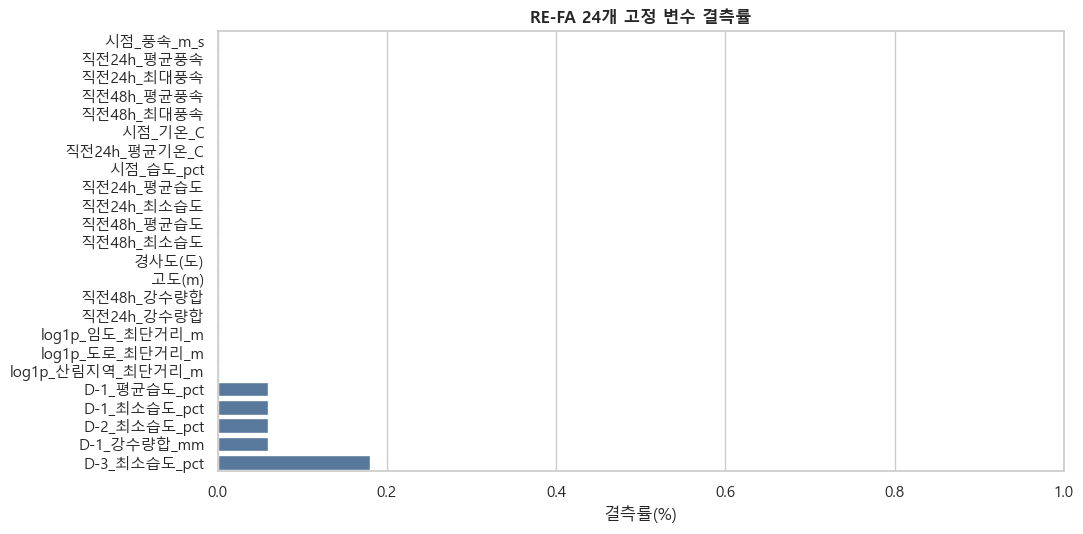

[1단계] 데이터 준비 완료
            항목       값
    산불 원자료 행 수 3405.00
  기상셀 매칭 후 행 수 3401.00
기상셀 미매칭 제외 행 수    4.00
    고정 FA 변수 수   24.00
 사용 가능 FA 변수 수   24.00
    누락 FA 변수 수    0.00
    완전 케이스 행 수 3395.00
 완전 케이스 비율_pct   99.82

결측률 상위 변수
          변수  전체행  유효표본수  결측수  결측률_pct
D-3_최소습도_pct 3401   3395    6     0.18
D-1_최소습도_pct 3401   3399    2     0.06
D-2_최소습도_pct 3401   3399    2     0.06
D-1_평균습도_pct 3401   3399    2     0.06
 D-1_강수량합_mm 3401   3399    2     0.06
   시점_풍속_m_s 3401   3401    0     0.00
  직전24h_최대풍속 3401   3401    0     0.00
  직전24h_평균풍속 3401   3401    0     0.00
   시점_습도_pct 3401   3401    0     0.00
직전24h_평균기온_C 3401   3401    0     0.00

저장: 파일 생성 안 함
플롯: 노트북에 표시됨


In [32]:
step1_result = run_step1_prep()


## [2단계] 요인분석 적합성 점검

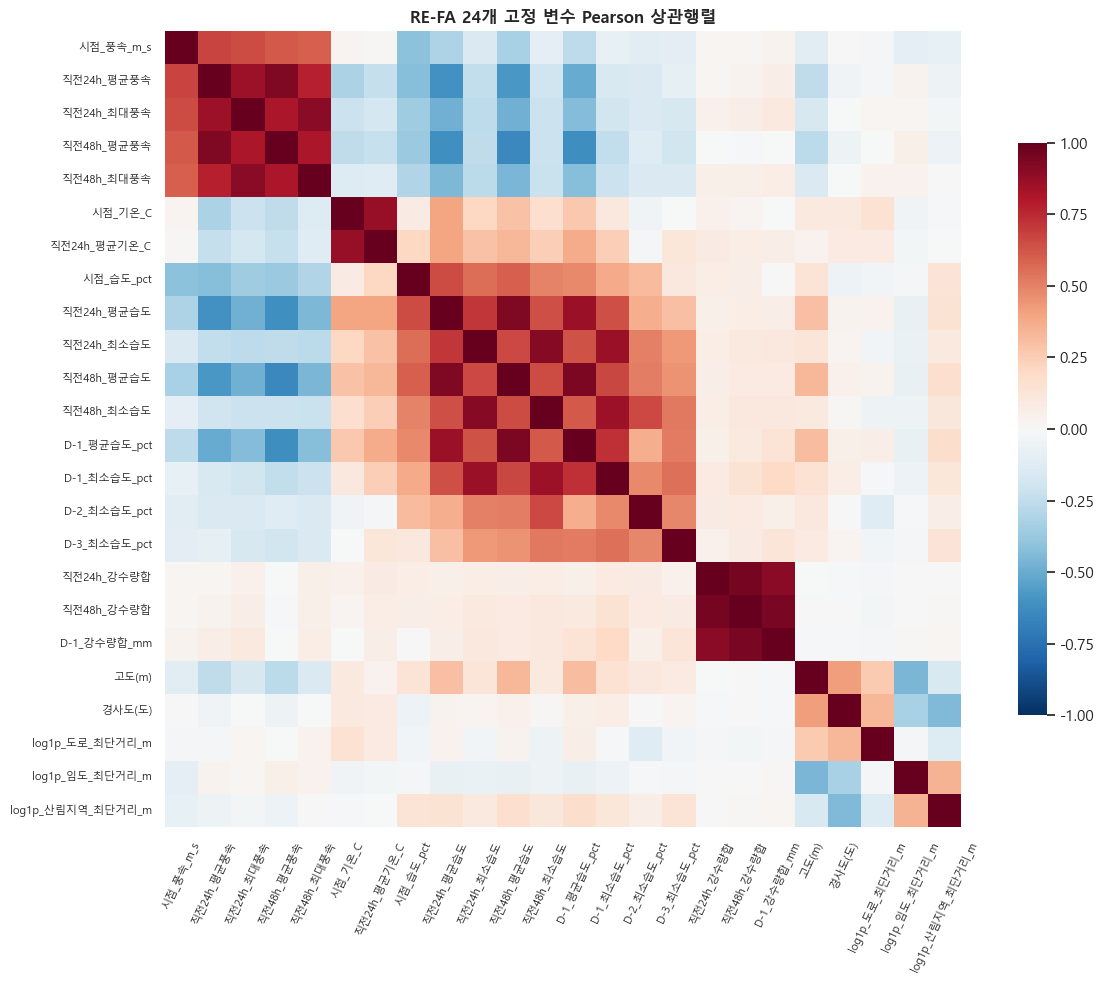

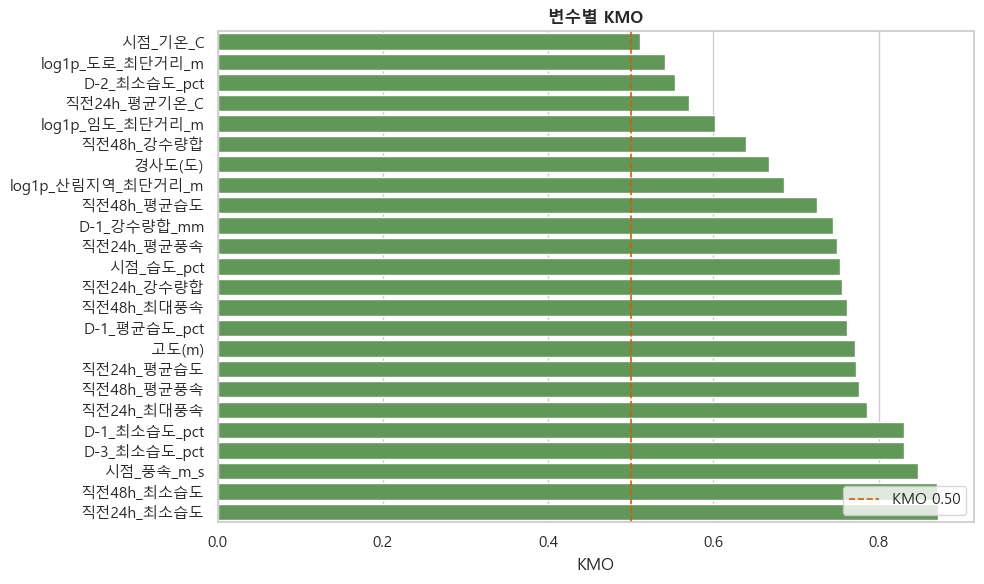

[2단계] 요인분석 적합성 점검 완료
                 지표            값                      해석
               표본 수  3395.000000               완전 케이스 기준
               변수 수    24.000000        상수/단일값 제거 후 변수 수
             KMO 전체     0.748317                   보통 이상
Bartlett chi-square 97512.180519   상관행렬이 단위행렬이라는 귀무가설 검정
   Bartlett p-value     0.000000 0.05 미만이면 요인분석 가능한 상관구조

변수별 KMO 값
               변수    KMO
          시점_기온_C 0.5109
  log1p_도로_최단거리_m 0.5417
     D-2_최소습도_pct 0.5533
     직전24h_평균기온_C 0.5704
  log1p_임도_최단거리_m 0.6015
       직전48h_강수량합 0.6398
           경사도(도) 0.6669
log1p_산림지역_최단거리_m 0.6851
       직전48h_평균습도 0.7256
      D-1_강수량합_mm 0.7444
       직전24h_평균풍속 0.7501
        시점_습도_pct 0.7528
       직전24h_강수량합 0.7555
       직전48h_최대풍속 0.7620
     D-1_평균습도_pct 0.7623
            고도(m) 0.7717
       직전24h_평균습도 0.7729
       직전48h_평균풍속 0.7767
       직전24h_최대풍속 0.7858
     D-1_최소습도_pct 0.8302
     D-3_최소습도_pct 0.8305
        시점_풍속_m_s 0.8479
       직전48h_최소습도 0.8710
       직전24h_최소습도 0.8718



In [33]:
step2_result = run_step2_factorability()


## [3단계] 요인 수 결정 (Scree Plot & Parallel Analysis)

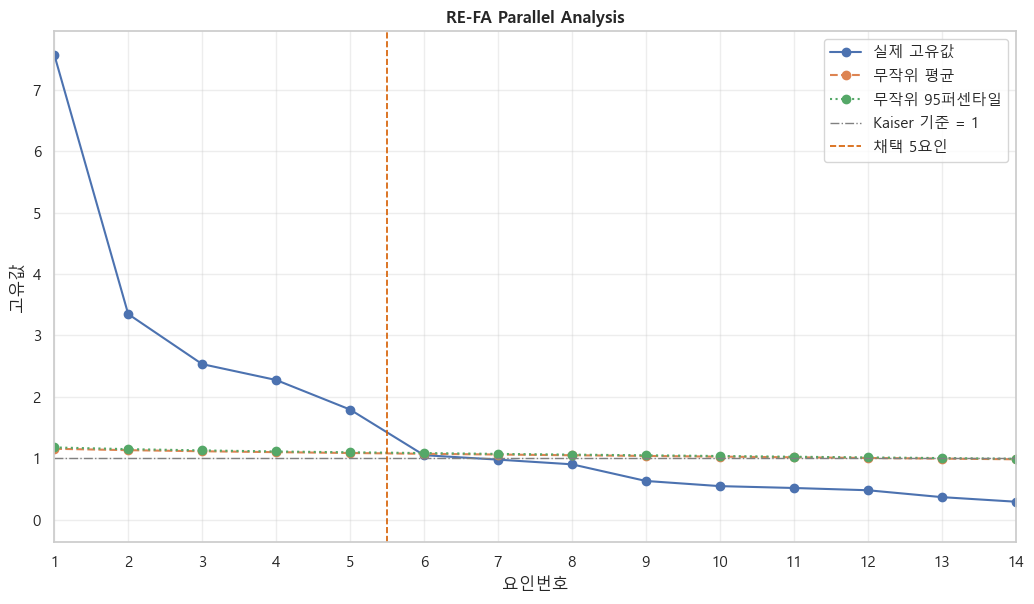

[3단계] Parallel Analysis 완료
                         기준  요인 수
Parallel Analysis 95퍼센타일 기준     5
    Parallel Analysis 평균 기준     5
  Kaiser 기준(eigenvalue > 1)     6
                 최종 채택 요인 수     5

고유값 비교표
 요인번호  observed_eigenvalue  random_mean  random_p95  observed_gt_random_mean  observed_gt_random_p95  kaiser_gt_1  p95_margin
    1               7.5763       1.1530      1.1749                     True                    True         True      6.4014
    2               3.3478       1.1303      1.1468                     True                    True         True      2.2010
    3               2.5323       1.1125      1.1268                     True                    True         True      1.4055
    4               2.2736       1.0978      1.1089                     True                    True         True      1.1648
    5               1.7921       1.0842      1.0957                     True                    True         True      0.6964
    6               1.0487       1.071

In [34]:
step3_result = run_step3_parallel_analysis()


## [4단계] 요인 회전 방식 비교 및 결정 (Varimax vs Promax)

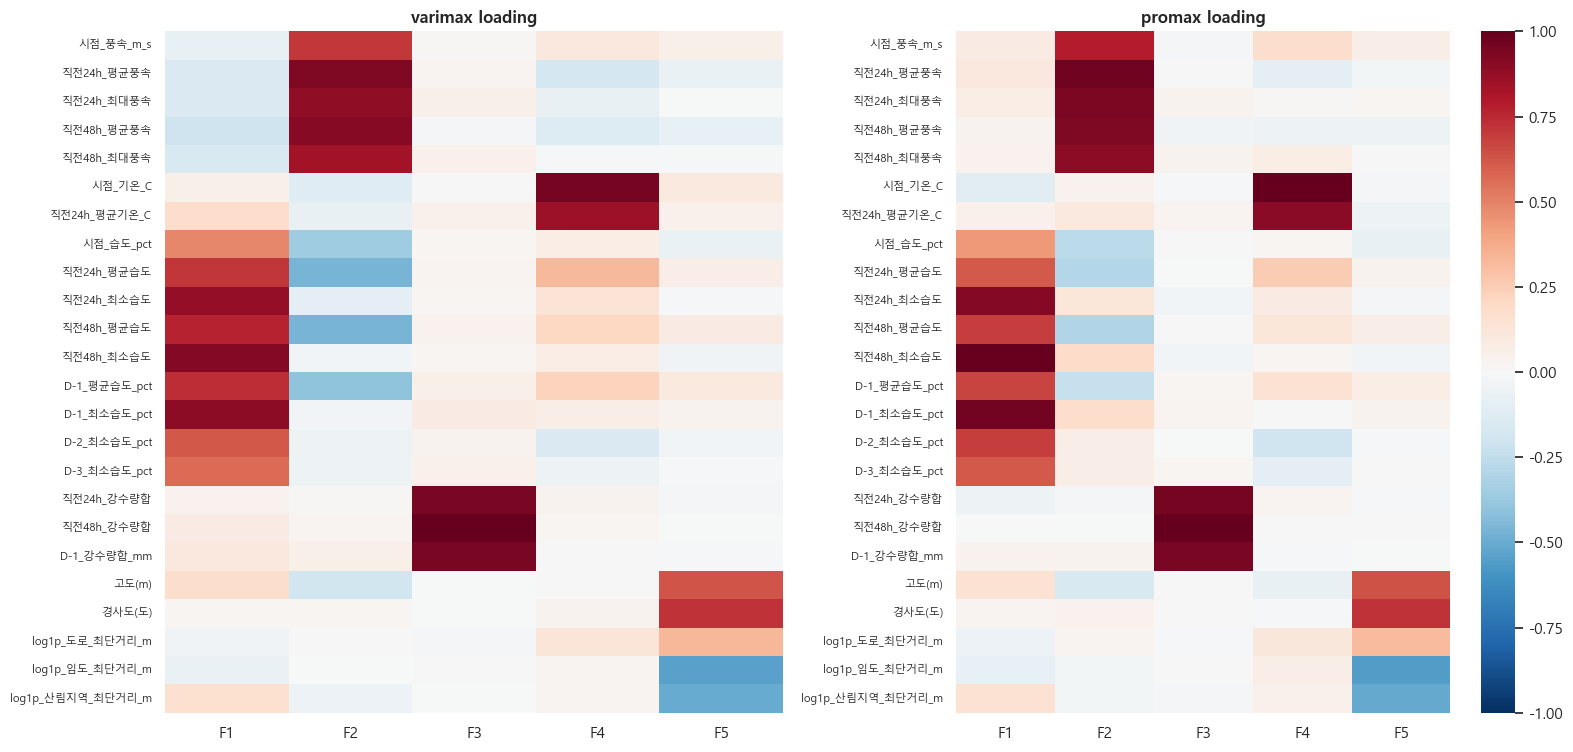

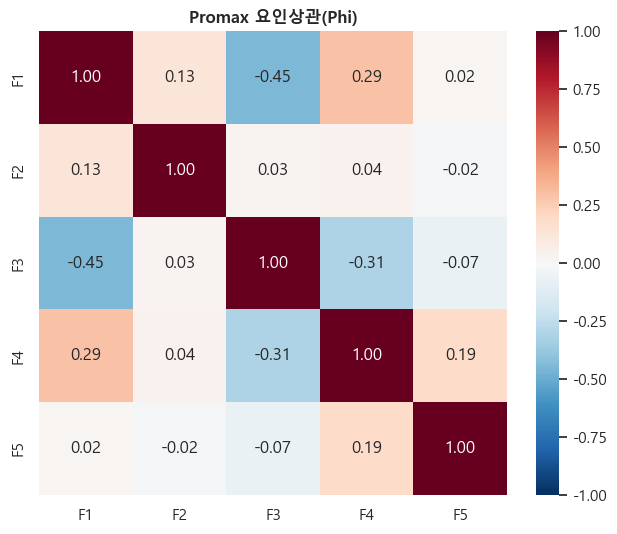

[4단계] 회전 방식 비교 완료
rotation  n_obs  n_vars  n_factors  mean_communality  min_communality  communality_lt_020_n  communality_gt_1_n  negative_uniqueness_n  weak_primary_loading_n  cross_loading_n  min_salient_vars_per_factor  max_abs_factor_corr  cumulative_variance
 varimax   3395      24          5            0.6743           0.1278                     1                   0                      0                       1                4                            2               0.0000               0.6743
  promax   3395      24          5            0.6797           0.1199                     1                   3                      3                       1                1                            2               0.4499               0.6797

선택: promax
근거: Promax 요인 간 최대 상관이 0.30 이상이어서 요인 간 상관을 허용하는 해석이 적절함

플롯: 노트북에 표시됨


In [35]:
step4_result = run_step4_rotation()


## [5단계] 요인 Loading 해석 및 잠재 요인 정의

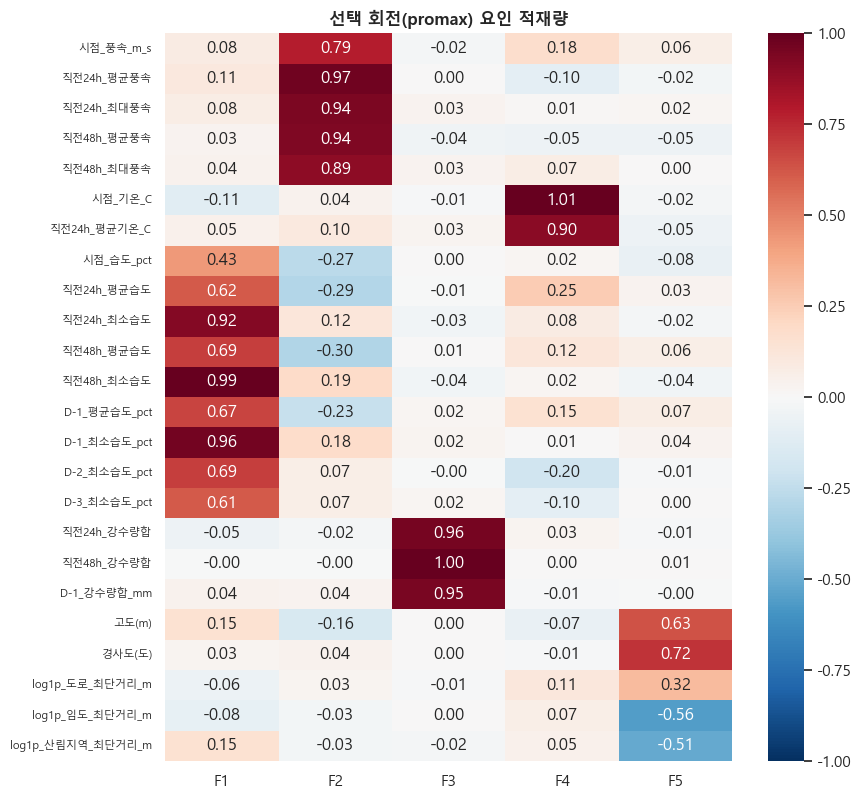

[5단계] Loading 해석 완료
요인               요인명          해석방향점수  부호보정                               해석방향                                                                                                   주요변수
F1      최소습도 기반 선행건조 F1_최소습도건조_score    -1         높을수록 직전·전일 최소습도가 낮은 극건조 상태 직전48h_최소습도, D-1_최소습도_pct, 직전24h_최소습도, D-2_최소습도_pct, 직전48h_평균습도, D-1_평균습도_pct, 직전24h_평균습도, D-3_최소습도_pct
F2          지속·최대 강풍     F2_강풍_score     1       높을수록 시점 및 직전 시간창 풍속이 큰 강풍 상태                                  직전24h_평균풍속, 직전24h_최대풍속, 직전48h_평균풍속, 직전48h_최대풍속, 시점_풍속_m_s, 직전48h_평균습도
F3        최근 강수/강수부족   F3_강수부족_score    -1            높을수록 최근 강수량이 적은 강수부족 상태                                                                    직전48h_강수량합, 직전24h_강수량합, D-1_강수량합_mm
F4          고온·기온 복합     F4_고온_score     1   높을수록 시점 및 직전 24시간 평균기온이 높은 고온 상태                                                                                  시점_기온_C, 직전24h_평균기온_C
F5 고도·경사-임도·산림 인접 지형  F5_산지접근성_score     1 높을수록 고도·경사가 크고 임도/산림지역과 가까운 산지 접

In [36]:
step5_result = run_step5_loading_interpretation()


## [6단계] 요인점수 생성 및 해석 방향 보정

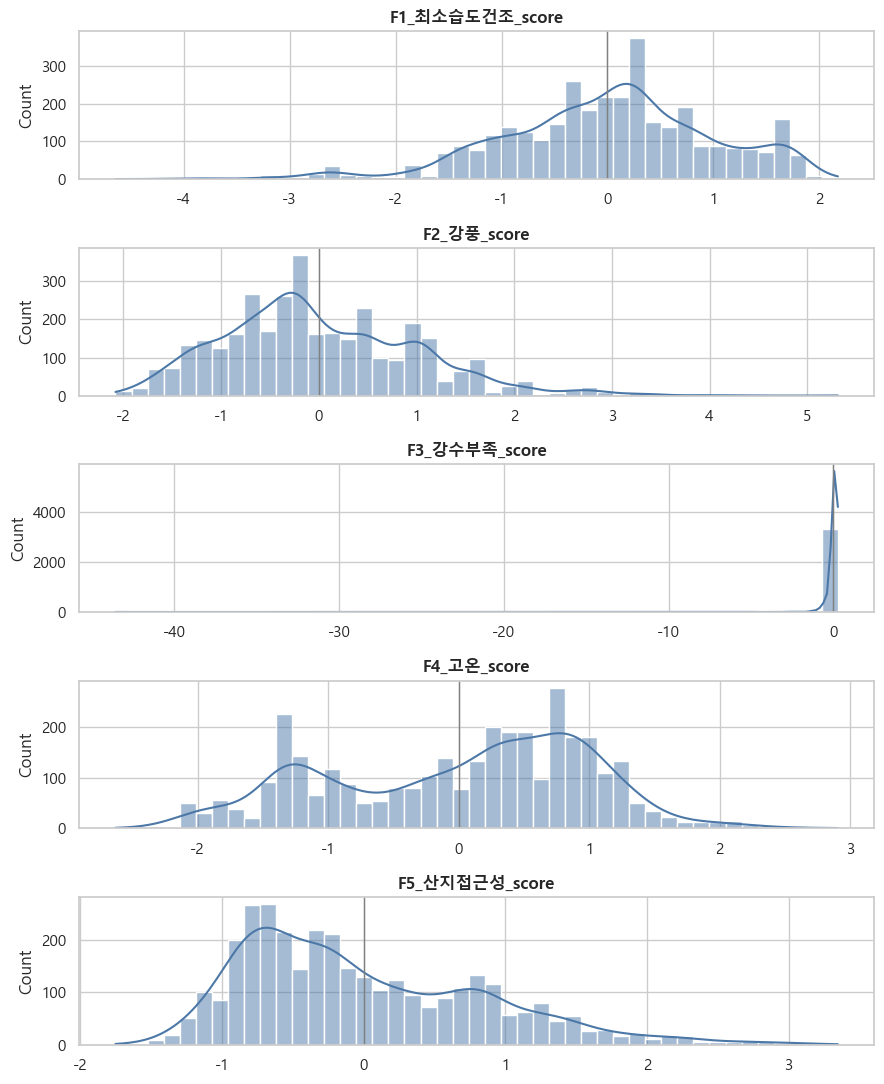

[6단계] 요인점수 생성 완료
요인               요인명    원점수컬럼          해석방향점수  부호보정       변환                               해석방향
F1      최소습도 기반 선행건조 F1_score F1_최소습도건조_score    -1 원점수 * -1         높을수록 직전·전일 최소습도가 낮은 극건조 상태
F2          지속·최대 강풍 F2_score     F2_강풍_score     1  원점수 그대로       높을수록 시점 및 직전 시간창 풍속이 큰 강풍 상태
F3        최근 강수/강수부족 F3_score   F3_강수부족_score    -1 원점수 * -1            높을수록 최근 강수량이 적은 강수부족 상태
F4          고온·기온 복합 F4_score     F4_고온_score     1  원점수 그대로   높을수록 시점 및 직전 24시간 평균기온이 높은 고온 상태
F5 고도·경사-임도·산림 인접 지형 F5_score  F5_산지접근성_score     1  원점수 그대로 높을수록 고도·경사가 크고 임도/산림지역과 가까운 산지 접근성

방향 보정 요인점수 기술통계
                  count  mean     std      min      1%      5%     50%     95%     99%     max     skew   kurtosis
F1_최소습도건조_score  3395.0  -0.0  0.9979  -4.6435 -2.7259 -1.4825  0.0701  1.6761  1.8078  2.1750  -0.4837     0.6857
F2_강풍_score      3395.0   0.0  0.9881  -2.0815 -1.7215 -1.4329 -0.1861  1.6574  2.7830  5.3136   0.6445     0.5841
F3_강수부족_score    3395.0   0.0  1.0010 -43.558

In [37]:
step6_result = run_step6_factor_scores()


## [7단계] 메타데이터별 요인점수 분석

### [7단계-기후지형유형] 기후지형유형별 요인점수 분석

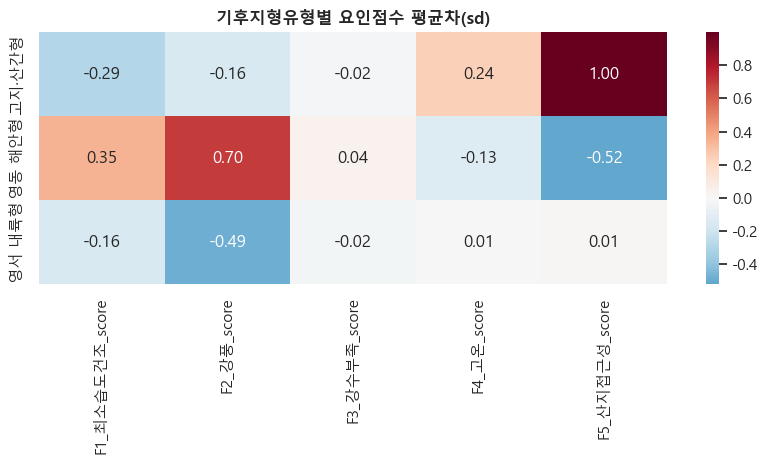

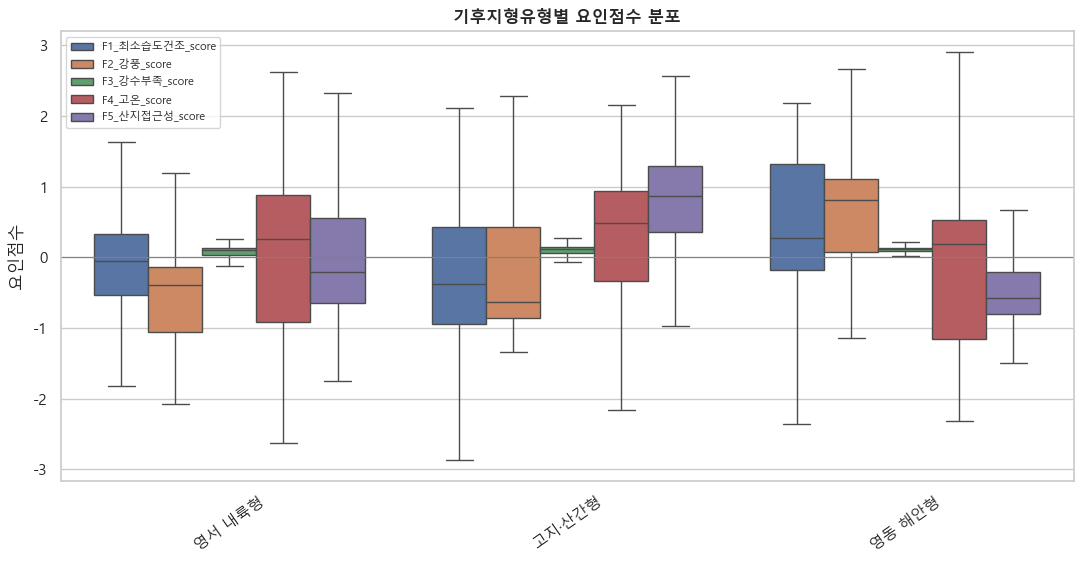

[7단계] 기후지형유형 메타데이터 분석 완료
요약표(groupby agg)
       F1_최소습도건조_score                       F2_강풍_score                       F3_강수부족_score                       F4_고온_score                       F5_산지접근성_score                      
                  mean     std count  median        mean     std count  median          mean     std count  median        mean     std count  median           mean     std count  median
기후지형유형                                                                                                                                                                                   
고지·산간형         -0.2921  0.8277   621 -0.3764     -0.1559  1.0341   621 -0.6352       -0.0212  0.5456   621  0.1155      0.2409  0.8809   621  0.4801         0.8634  0.7447   621  0.8717
영동 해안형          0.3494  1.1254  1218  0.2744      0.6930  0.7877  1218  0.8050        0.0412  0.9624  1218  0.1126     -0.1313  0.9094  1218  0.1820        -0.4505  0.5674  1218 -0.5815
영서 내륙형         -0.1569  0.86

In [46]:
step7_climate_terrain = run_step7_one_metadata('기후지형유형')


### [7단계-addr_type] addr_type별 요인점수 분석

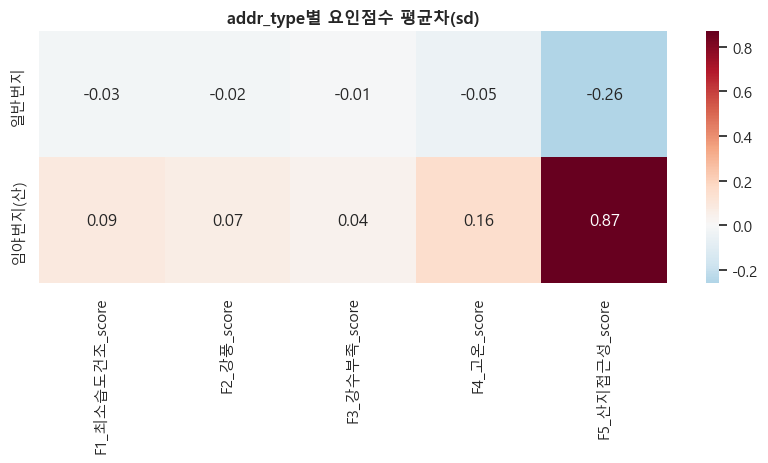

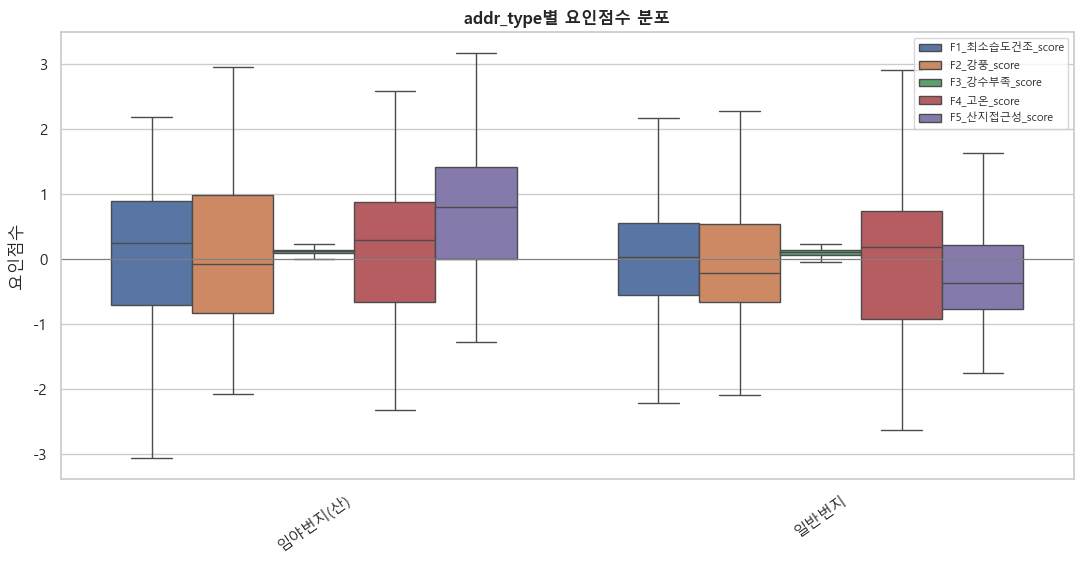

[7단계] addr_type 메타데이터 분석 완료
요약표(groupby agg)
          F1_최소습도건조_score                       F2_강풍_score                       F3_강수부족_score                       F4_고온_score                       F5_산지접근성_score                      
                     mean     std count  median        mean     std count  median          mean     std count  median        mean     std count  median           mean     std count  median
addr_type                                                                                                                                                                                   
일반번지              -0.0255  0.9380  2611  0.0329     -0.0195  0.9652  2611 -0.2085       -0.0124  1.1237  2611  0.1056     -0.0464  0.9909  2611  0.1906        -0.2256  0.7174  2611 -0.3741
임야번지(산)            0.0849  1.1722   784  0.2521      0.0651  1.0590   784 -0.0821        0.0414  0.3640   784  0.1179      0.1545  0.9853   784  0.2984         0.7512  0.8863   784  0.7971

Kruskal-W

In [39]:
step7_addr_type = run_step7_one_metadata('addr_type')


### [7단계-기후지형_번지유형] 기후지형_번지유형별 요인점수 분석

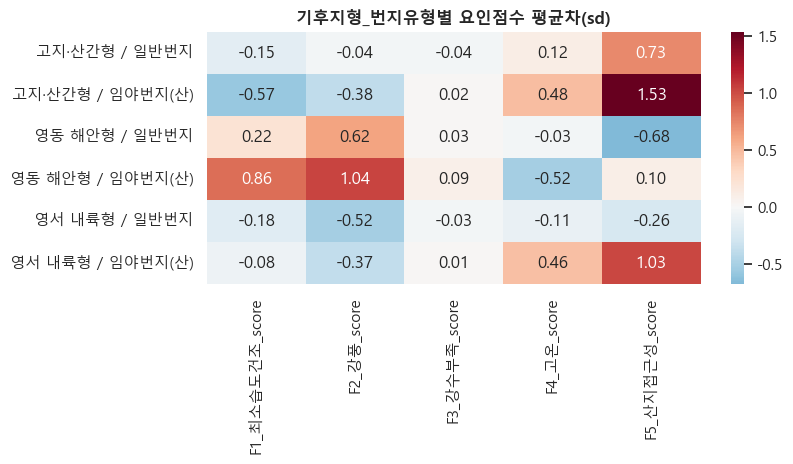

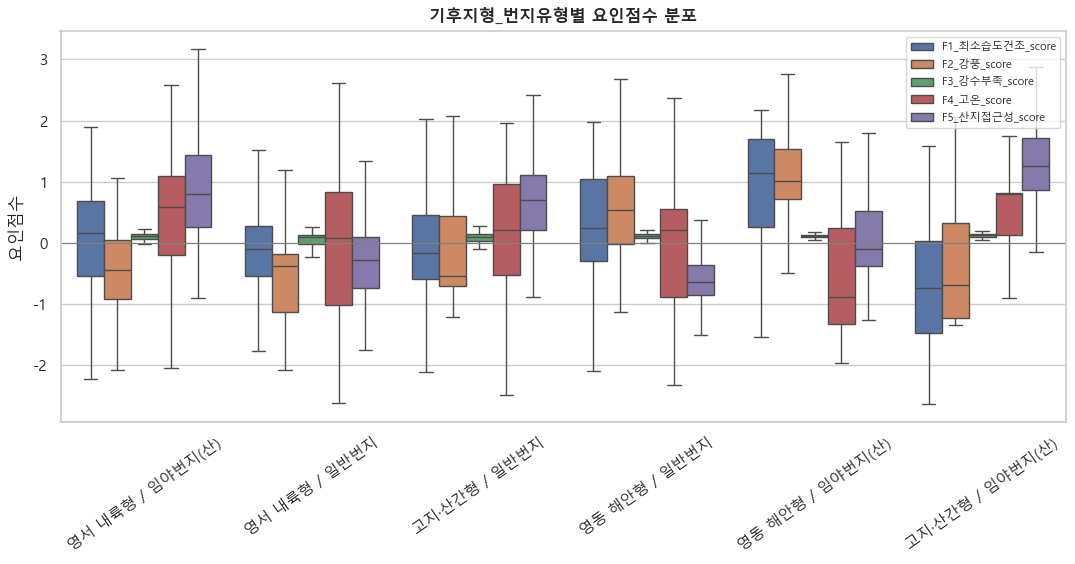

[7단계] 기후지형_번지유형 메타데이터 분석 완료
요약표(groupby agg)
                 F1_최소습도건조_score                       F2_강풍_score                       F3_강수부족_score                       F4_고온_score                       F5_산지접근성_score                      
                            mean     std count  median        mean     std count  median          mean     std count  median        mean     std count  median           mean     std count  median
기후지형_번지유형                                                                                                                                                                                          
고지·산간형 / 일반번지            -0.1521  0.7566   412 -0.1663     -0.0424  1.0372   412 -0.5417       -0.0446  0.6131   412  0.0996      0.1230  0.9035   412  0.2074         0.6306  0.6807   412  0.6958
고지·산간형 / 임야번지(산)         -0.5681  0.8920   209 -0.7405     -0.3796  0.9931   209 -0.6863        0.0248  0.3758   209  0.1355      0.4733  0.7863   209  0.7988         1.32

In [40]:
step7_climate_addr = run_step7_one_metadata('기후지형_번지유형')


### [7단계-산불위험계절] 산불위험계절별 요인점수 분석

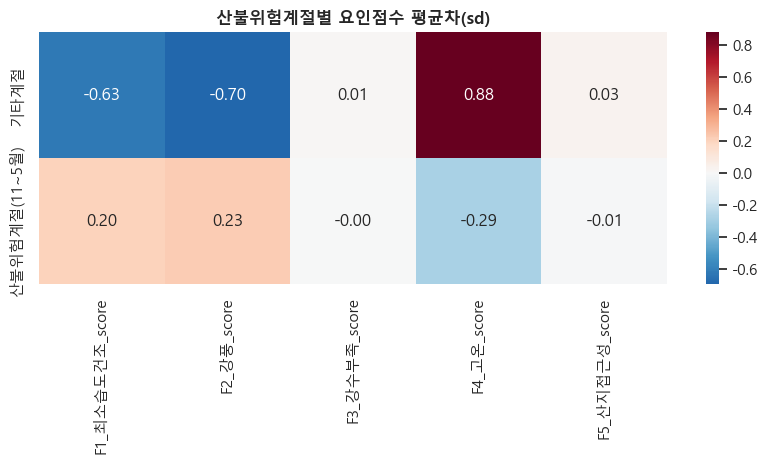

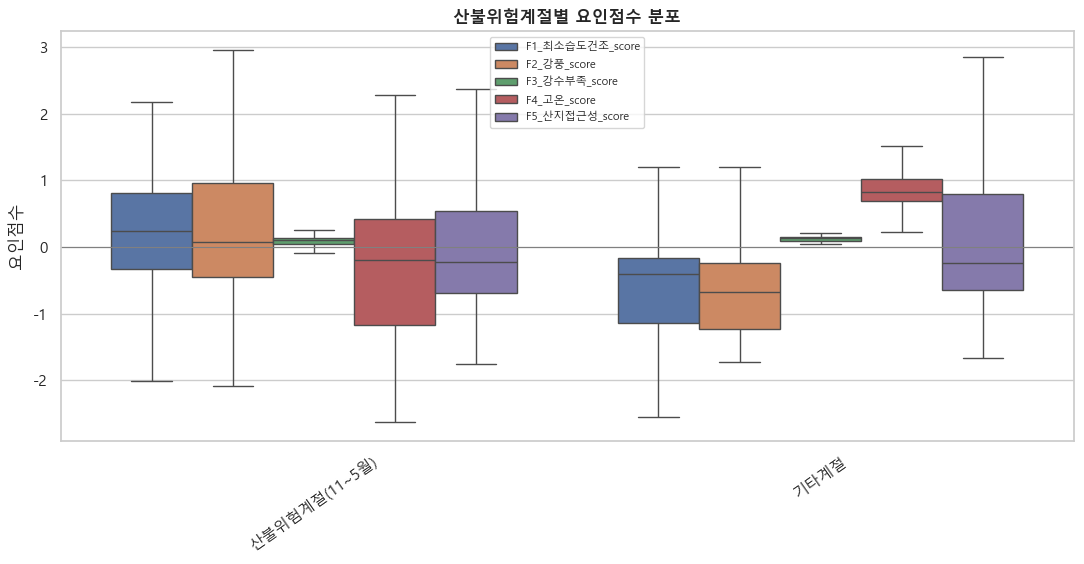

[7단계] 산불위험계절 메타데이터 분석 완료
요약표(groupby agg)
              F1_최소습도건조_score                       F2_강풍_score                       F3_강수부족_score                       F4_고온_score                       F5_산지접근성_score                      
                         mean     std count  median        mean     std count  median          mean     std count  median        mean     std count  median           mean     std count  median
산불위험계절                                                                                                                                                                                          
기타계절                  -0.6282  0.6545   830 -0.4000     -0.6895  0.6672   830 -0.6786        0.0110  1.8882   830  0.1290      0.8777  0.3776   830  0.8313         0.0290  0.8011   830 -0.2432
산불위험계절(11~5월)          0.2033  1.0052  2565  0.2414      0.2231  0.9720  2565  0.0803       -0.0036  0.4167  2565  0.1029     -0.2840  0.9640  2565 -0.1915        -0.0094  0.8833  2565 -

In [41]:
step7_fire_season = run_step7_one_metadata('산불위험계절')


### [7단계-L1_NAME] L1_NAME별 요인점수 분석

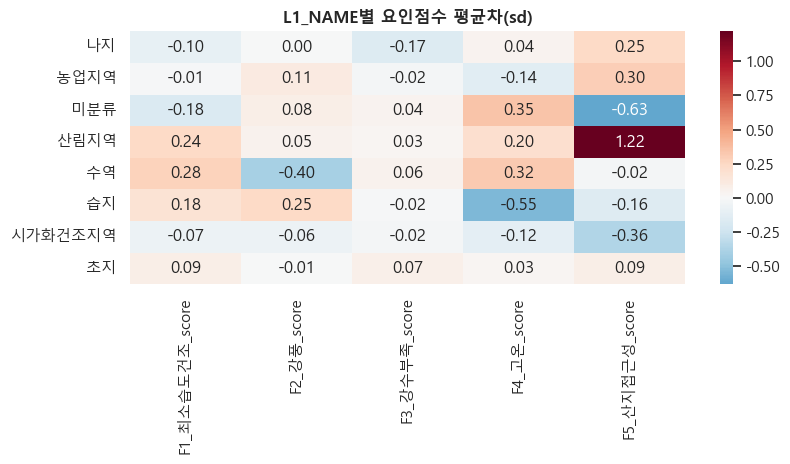

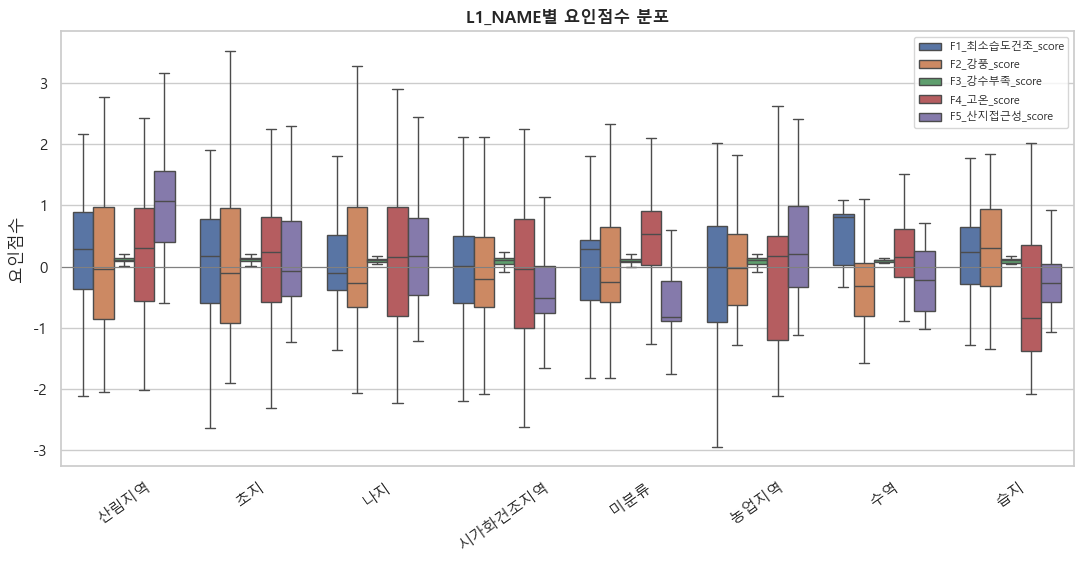

[7단계] L1_NAME 메타데이터 분석 완료
요약표(groupby agg)
        F1_최소습도건조_score                       F2_강풍_score                       F3_강수부족_score                       F4_고온_score                       F5_산지접근성_score                      
                   mean     std count  median        mean     std count  median          mean     std count  median        mean     std count  median           mean     std count  median
L1_NAME                                                                                                                                                                                   
나지              -0.0955  1.0926   207 -0.1052      0.0003  1.1073   207 -0.2642       -0.1659  2.2745   207  0.1133      0.0419  1.0143   207  0.1597         0.2130  0.7900   207  0.1756
농업지역            -0.0135  0.9954   286 -0.0040      0.1045  0.8202   286 -0.0192       -0.0247  0.3383   286  0.1050     -0.1359  0.9938   286  0.1761         0.2584  0.7551   286  0.2048
미분류             -0.176

In [42]:
step7_l1 = run_step7_one_metadata('L1_NAME')


### [7단계-L2_NAME] L2_NAME별 요인점수 분석

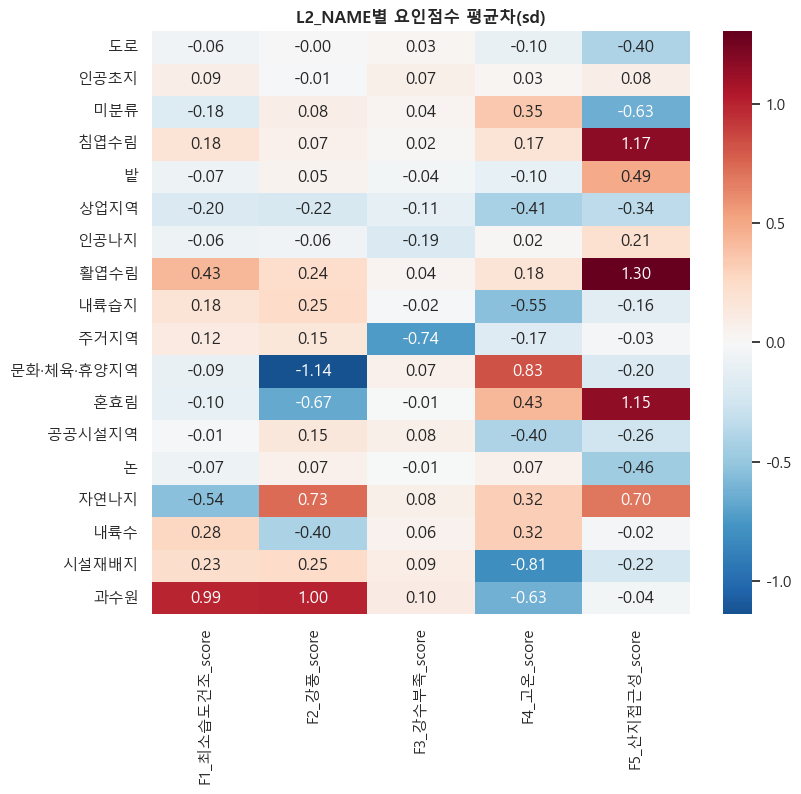

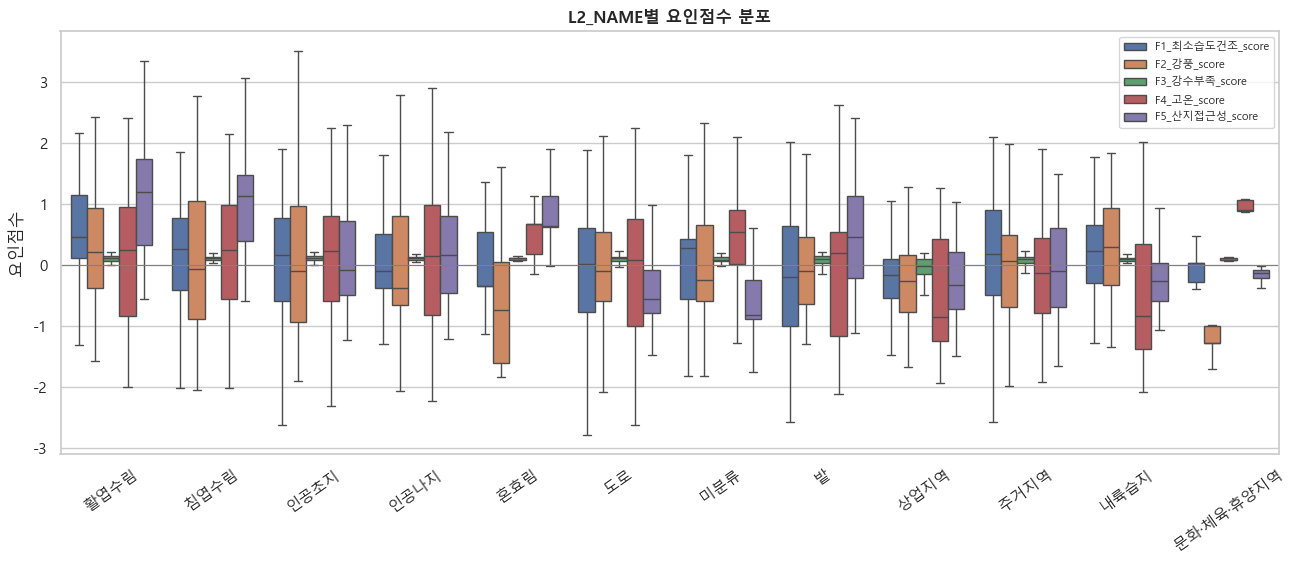

[7단계] L2_NAME 메타데이터 분석 완료
요약표(groupby agg)
           F1_최소습도건조_score                       F2_강풍_score                       F3_강수부족_score                       F4_고온_score                       F5_산지접근성_score                      
                      mean     std count  median        mean     std count  median          mean     std count  median        mean     std count  median           mean     std count  median
L2_NAME                                                                                                                                                                                      
공공시설지역             -0.0144  0.9489    40  0.1739      0.1454  1.3617    40 -0.2674        0.0770  0.1065    40  0.1060     -0.3938  1.0601    40 -0.5998        -0.2232  0.6202    40 -0.2822
과수원                 0.9911  1.3788    12  1.6956      0.9890  0.6305    12  0.9968        0.1045  0.0226    12  0.0969     -0.6212  1.0529    12 -1.3284        -0.0310  0.5423    12 -0.0960
교통지역   

In [43]:
step7_l2 = run_step7_one_metadata('L2_NAME')


### [7단계-산림세부유형] 산림세부유형별 요인점수 분석

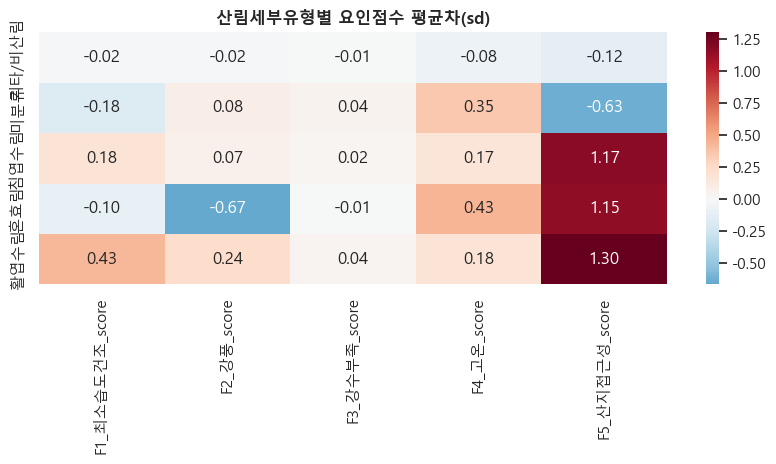

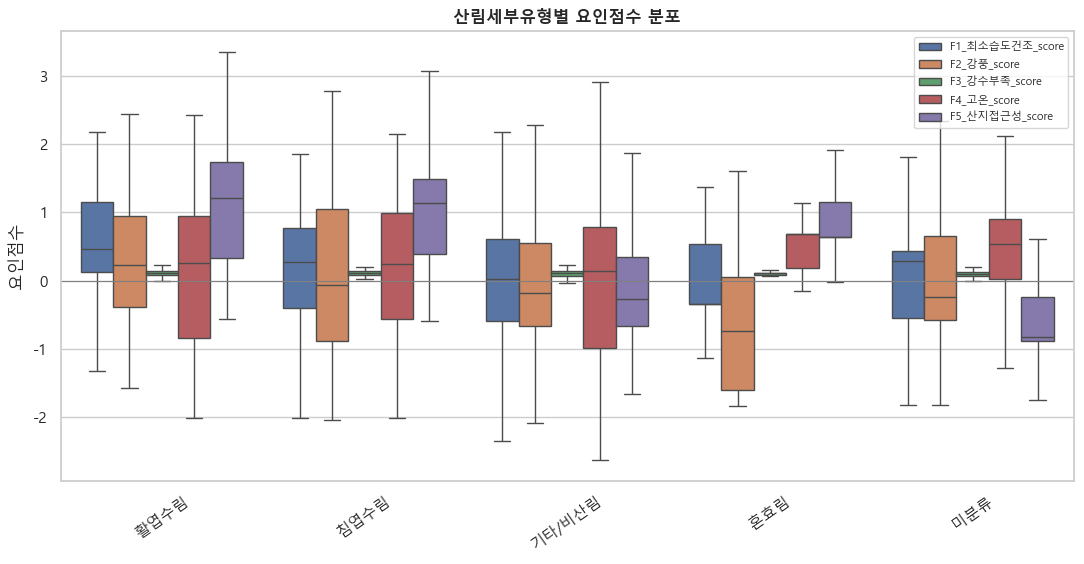

[7단계] 산림세부유형 메타데이터 분석 완료
요약표(groupby agg)
       F1_최소습도건조_score                       F2_강풍_score                       F3_강수부족_score                       F4_고온_score                       F5_산지접근성_score                      
                  mean     std count  median        mean     std count  median          mean     std count  median        mean     std count  median           mean     std count  median
산림세부유형                                                                                                                                                                                   
기타/비산림         -0.0182  0.9616  2603  0.0224     -0.0201  0.9564  2603 -0.1777       -0.0102  1.1073  2603  0.1113     -0.0810  0.9949  2603  0.1415        -0.1071  0.7371  2603 -0.2760
미분류            -0.1765  1.1957   347  0.2825      0.0835  1.1617   347 -0.2484        0.0437  0.3199   347  0.0899      0.3481  0.8705   347  0.5355        -0.5480  0.6575   347 -0.8276
침엽수림            0.1793  0.99

In [44]:
step7_forest_subtype = run_step7_one_metadata('산림세부유형')
